In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from numba import njit
import os


In [ ]:
L = 50.0          # domain size
Nx = 512          # number of grid points
dx = L / Nx
x = np.linspace(0, L, Nx)

Ds = 1
rs = 1
Ks = 2.0


Km = 1.0
v0 = 5

rq = 0.2

lam = 0.5
a = -1.0
b = 1.0
c = 2
gamma = 1

alpha = 0.2

rb = np.ones_like(x) * 0.02
# rb = 0.2 * np.exp(-((x - L/5)**2) / (2*(L/20)**2))


def laplacian(u):
    lap = np.zeros_like(u)
    lap[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    lap[0] = lap[1]       # Neumann BC
    lap[-1] = lap[-2]
    return lap

def gradient(u):
    grad = np.zeros_like(u)
    grad[1:-1] = (u[2:] - u[:-2]) / (2*dx)
    grad[0] = grad[1]
    grad[-1] = grad[-2]
    return grad


def rhs(t, Y):
    s = Y[0:Nx]
    m = Y[Nx:2*Nx]
    p = Y[2*Nx:3*Nx]
    q = Y[3*Nx:4*Nx]

    ds = (
        Ds * laplacian(s)
        + rs * s * (1 - s)
        - Ks * m * s
        - (rq * np.abs(q) + rb) * s
    )

    flux = v0 * m * p
    dm = (
        -gradient(flux)
        + laplacian(m)
        + m * (1 - m)
        - Km * m * s
        + (rq * np.abs(q) + rb) * s
    )

    dp = -lam * (
        a * p
        + b * p**3
        - c * laplacian(p)
        + 2 * gamma * p
        - gamma * q
    )

    dq = alpha * m * p * (1 - np.abs(q))

    p[0] = 0
    p[1] = 0
    p[-1] = 0
    p[-2] = 0

    return np.concatenate([ds, dm, dp, dq])


In [177]:
s0 = np.ones_like(x)
m0 = np.zeros_like(x)

np.random.seed(1111)

a, b = -1, 1

p0 = np.zeros_like(x) + 0.01 * ((b - a) * np.random.random_sample(Nx) + a)
p0[0] = 0
p0[1] = 0
p0[-1] = 0
p0[-2] = 0
q0 = np.zeros_like(x)

Y0 = np.concatenate([s0, m0, p0, q0])


t_span = (0, 200)
t_eval = np.linspace(*t_span, 150)



sol = solve_ivp(
    rhs, t_span, Y0,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-6,
    atol=1e-8
)


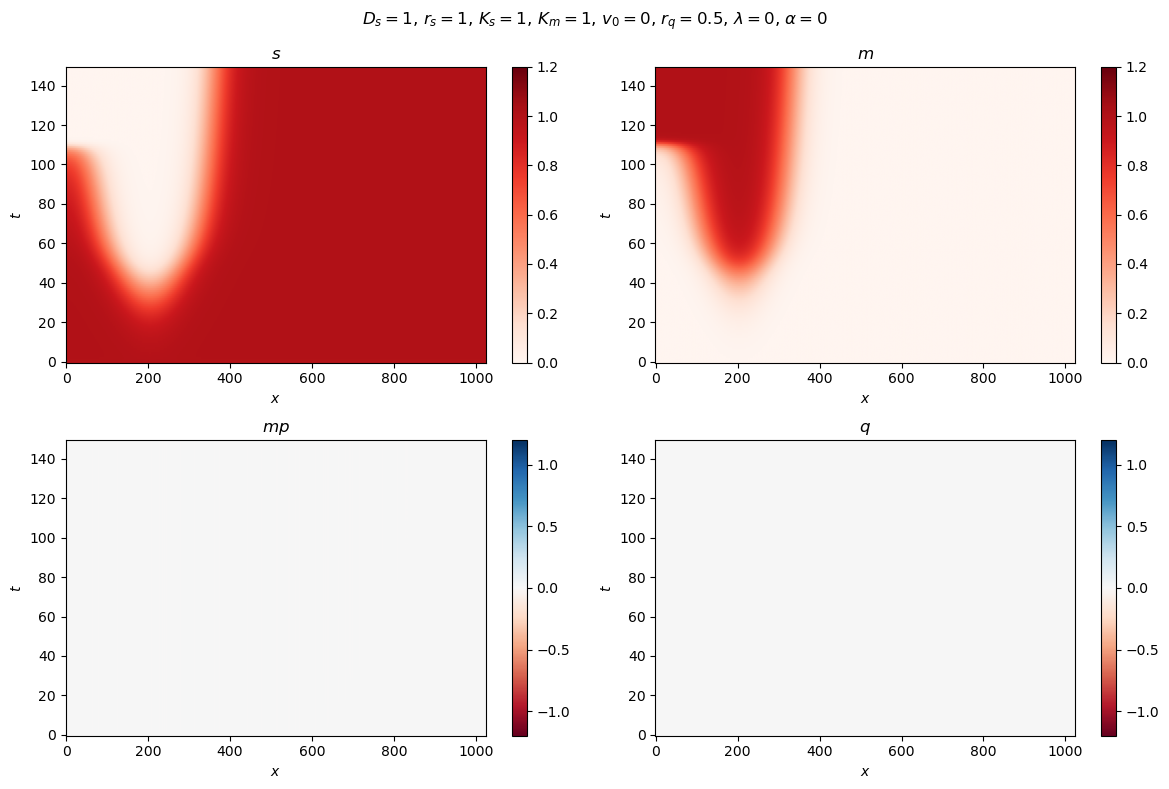

In [137]:
s = sol.y[0:Nx]
m = sol.y[Nx:2*Nx]
p = sol.y[2*Nx:3*Nx]
q = sol.y[3*Nx:4*Nx]


fig, axs = plt.subplots(2, 2, figsize=(12, 8))

plt.suptitle(f'$D_s = {Ds}$, $r_s = {rs}$, $K_s = {Ks}$, $K_m = {Km}$, $v_0 = {v0}$, $r_q = {rq}$, $\\lambda = {lam}$, $\\alpha = {alpha}$')

clim = (0, 1.2)

im1 = axs[0,0].imshow(s.T, aspect='auto', origin='lower', cmap='Reds', clim=clim)
axs[0,0].set_title(r'$s$')
axs[0,0].set_xlabel(r'$x$')
axs[0,0].set_ylabel(r'$t$')
plt.colorbar(im1, ax=axs[0,0])

im2 = axs[0,1].imshow(m.T, aspect='auto', origin='lower', cmap='Reds', clim=clim)
axs[0,1].set_title(r'$m$')
axs[0,1].set_xlabel(r'$x$')
axs[0,1].set_ylabel(r'$t$')
plt.colorbar(im2, ax=axs[0,1])

clim = (-1.2, 1.2)

im3 = axs[1,0].imshow((m * p).T, aspect='auto', origin='lower', cmap='RdBu', clim=clim)
axs[1,0].set_title(r'$mp$')
axs[1,0].set_xlabel(r'$x$')
axs[1,0].set_ylabel(r'$t$')
plt.colorbar(im3, ax=axs[1,0])

im4 = axs[1,1].imshow(q.T, aspect='auto', origin='lower', cmap='RdBu', clim=clim)
axs[1,1].set_title(r'$q$')
axs[1,1].set_xlabel(r'$x$')
axs[1,1].set_ylabel(r'$t$')
plt.colorbar(im4, ax=axs[1,1])


plt.tight_layout()

[0.10949804 0.10949804 0.10949805 0.10949806 0.10949808 0.10949811
 0.10949815 0.10949819 0.10949823 0.10949829 0.10949835 0.10949841
 0.10949848 0.10949856 0.10949864 0.10949872 0.1094988  0.10949889
 0.10949898 0.10949907 0.10949916 0.10949925 0.10949934 0.10949943
 0.10949951 0.10949959 0.10949968 0.10949975 0.10949983 0.10949989
 0.10949996 0.10950002 0.10950008 0.10950013 0.10950018 0.10950023
 0.10950027 0.10950032 0.10950036 0.10950039 0.10950043 0.10950047
 0.10950051 0.10950055 0.10950059 0.10950063 0.10950066 0.10950069
 0.10950072 0.10950074 0.10950076 0.10950077 0.10950078 0.10950079
 0.10950079 0.10950078 0.10950078 0.10950076 0.10950074 0.10950072
 0.1095007  0.10950067 0.10950064 0.1095006  0.10950056 0.10950052
 0.10950047 0.10950042 0.10950037 0.10950032 0.10950026 0.1095002
 0.10950013 0.10950007 0.10949999 0.10949992 0.10949984 0.10949976
 0.10949967 0.10949958 0.10949949 0.10949939 0.10949929 0.10949919
 0.10949908 0.10949897 0.10949886 0.10949875 0.10949864 0.10949

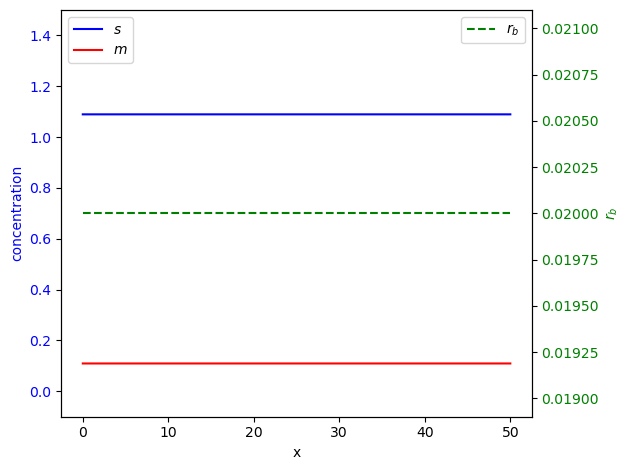

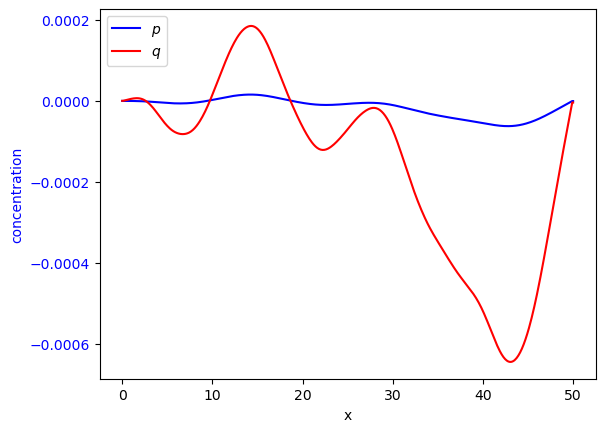

In [141]:
fig, ax1 = plt.subplots()

ax1.plot(x, s[:, 80], 'b-', label=r'$s$')
ax1.plot(x, m[:, 80], 'r-', label=r'$m$')
ax1.set_xlabel('x')
ax1.set_ylabel('concentration', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.legend(loc='upper left')

plt.ylim(-0.1, 1.5)

print(m[:, 20])

ax2 = ax1.twinx()
ax2.plot(x, rb, 'g--', label=r'$r_b$')
ax2.set_ylabel(r'$r_b$', color='g')
ax2.tick_params(axis='y', labelcolor='g')
ax2.legend(loc='upper right')

fig.tight_layout()
# plt.savefig('phase_field_final_homo.png', dpi=300)


fig, ax1 = plt.subplots()

ax1.plot(x, m[:, -1] * p[:, -1], 'b-', label=r'$p$')
ax1.plot(x, q[:, -1], 'r-', label=r'$q$')
ax1.set_xlabel('x')
ax1.set_ylabel('concentration', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.legend(loc='upper left')

# V2

In [32]:
L = 50.0          # domain size
Nx = 512        # number of grid points
dx = L / Nx
x = np.linspace(0, L, Nx)

K = 1
v0 = 5

rq = 0.0

lam = 1
a = -1.0
b = 1.0
c = 1
gamma = 1

alpha = 1

bd = 'gauss'
rbm = 0.85

if bd == 'homo':
    rb = np.ones_like(x) * rbm

elif bd == 'gauss':
    rb = rbm * np.exp(-((x - L/5)**2) / (2*(L/20)**2))


def laplacian(u):
    lap = np.zeros_like(u)
    lap[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    lap[0] = lap[1]       # Neumann BC
    lap[-1] = lap[-2]
    return lap

def gradient(u):
    grad = np.zeros_like(u)
    grad[1:-1] = (u[2:] - u[:-2]) / (2*dx)
    grad[0] = grad[1]
    grad[-1] = grad[-2]
    return grad


def rhs(t, Y):
    s = Y[0:Nx]
    m = Y[Nx:2*Nx]
    p = Y[2*Nx:3*Nx]
    q = Y[3*Nx:4*Nx]

    ds = (
        laplacian(s)
        + s * (1 - (s + m))
        - K * m * s
        - (rq * np.abs(q) + rb) * s * (1 - (s + m))
    )

    flux = v0 * m * p
    dm = (
        -gradient(flux)
        + laplacian(m)
        + m * (1 - (m + s))
        - K * m * s
        + (rq * np.abs(q) + rb) * s * (1 - (s + m))
    )

    dp = -lam * (
        a * p
        + b * p**3
        - c * laplacian(p)
        + 2 * gamma * p
        - gamma * q
    )

    dq = alpha * m * p * (1 - np.abs(q))

    p[0] = 0
    p[1] = 0
    p[-1] = 0
    p[-2] = 0

    return np.concatenate([ds, dm, dp, dq])


In [33]:
s0 = np.ones_like(x) * 0.99
m0 = np.zeros_like(x)

np.random.seed(1234)

a, b = -1, 1

p0 = np.zeros_like(x) + 0.00001 * ((b - a) * np.random.random_sample(Nx) + a)
p0[0] = 0
p0[1] = 0
p0[-1] = 0
p0[-2] = 0
q0 = np.zeros_like(x)

Y0 = np.concatenate([s0, m0, p0, q0])


t_span = (0, 200)
t_eval = np.linspace(*t_span, 150)



sol = solve_ivp(
    rhs, t_span, Y0,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-6,
    atol=1e-8
)


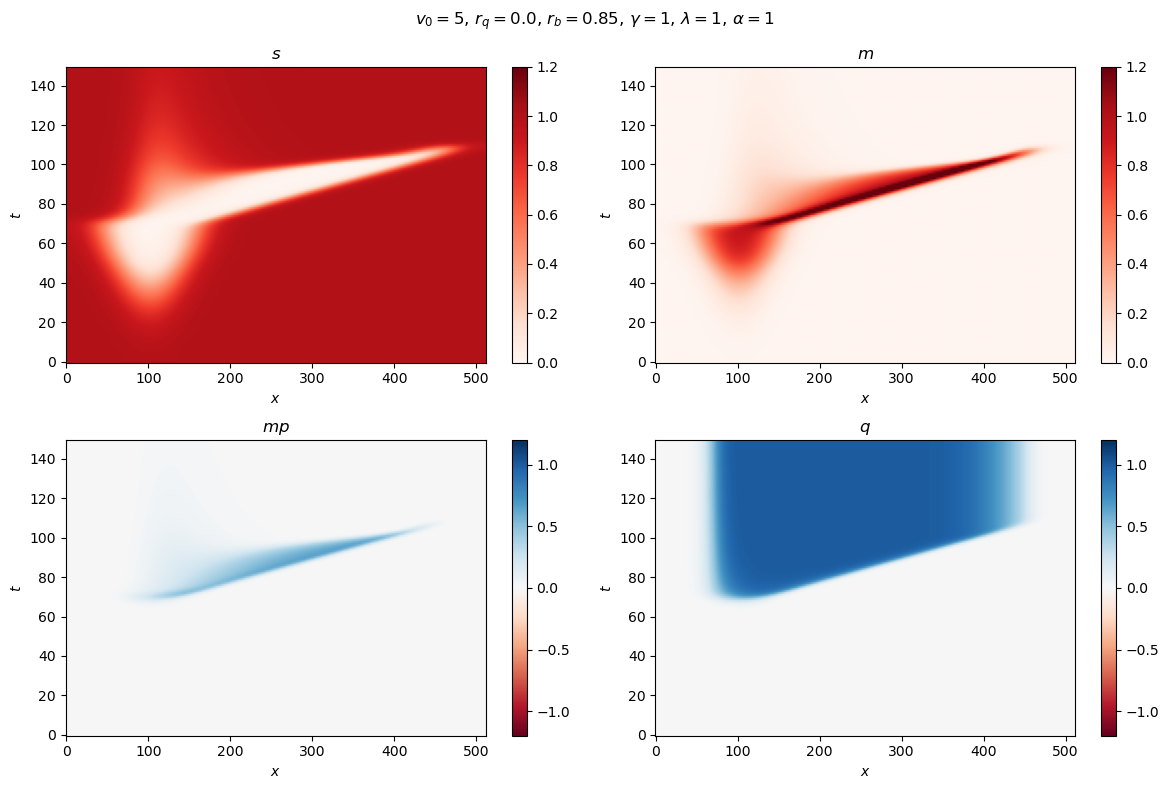

In [34]:
s = sol.y[0:Nx]
m = sol.y[Nx:2*Nx]
p = sol.y[2*Nx:3*Nx]
q = sol.y[3*Nx:4*Nx]


fig, axs = plt.subplots(2, 2, figsize=(12, 8))

plt.suptitle(f'$v_0 = {v0}$, $r_q = {rq}$, $r_b = {rbm}$, $\\gamma = {gamma}$, $\\lambda = {lam}$, $\\alpha = {alpha}$')

clim = (0, 1.2)

im1 = axs[0,0].imshow(s.T, aspect='auto', origin='lower', cmap='Reds', clim=clim)
axs[0,0].set_title(r'$s$')
axs[0,0].set_xlabel(r'$x$')
axs[0,0].set_ylabel(r'$t$')
plt.colorbar(im1, ax=axs[0,0])

im2 = axs[0,1].imshow(m.T, aspect='auto', origin='lower', cmap='Reds', clim=clim)
axs[0,1].set_title(r'$m$')
axs[0,1].set_xlabel(r'$x$')
axs[0,1].set_ylabel(r'$t$')
plt.colorbar(im2, ax=axs[0,1])

clim = (-1.2, 1.2)

im3 = axs[1,0].imshow((m * p).T, aspect='auto', origin='lower', cmap='RdBu', clim=clim)
axs[1,0].set_title(r'$mp$')
axs[1,0].set_xlabel(r'$x$')
axs[1,0].set_ylabel(r'$t$')
plt.colorbar(im3, ax=axs[1,0])

im4 = axs[1,1].imshow(q.T, aspect='auto', origin='lower', cmap='RdBu', clim=clim)
axs[1,1].set_title(r'$q$')
axs[1,1].set_xlabel(r'$x$')
axs[1,1].set_ylabel(r'$t$')
plt.colorbar(im4, ax=axs[1,1])

plt.tight_layout()

fig_name = f'phase_field_{bd}_K{K}_v0{v0}_rq{rq}_rb_{rbm}_lam{lam}_alpha{alpha}_xt.png'
plt.savefig(fig_name, dpi=300)

# V3: No logistic growth

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from numba import njit
import os


In [26]:
L = 50.0          # domain size
Nx = 512        # number of grid points
dx = L / Nx
x = np.linspace(0, L, Nx)

Km = 1
Ks = 0
v0 = 5

rq = 1

lam = 1
a = -1.0
b = 1.0
c = 1
gamma = 1

alpha = 1

bd = 'gauss'
rbm = 0.8

if bd == 'homo':
    rb = np.ones_like(x) * rbm

elif bd == 'gauss':
    rb = rbm * np.exp(-((x - L/5)**2) / (2*(L/20)**2))


def laplacian(u):
    lap = np.zeros_like(u)
    lap[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    lap[0] = lap[1]       # Neumann BC
    lap[-1] = lap[-2]
    return lap

def gradient(u):
    grad = np.zeros_like(u)
    grad[1:-1] = (u[2:] - u[:-2]) / (2*dx)
    grad[0] = grad[1]
    grad[-1] = grad[-2]
    return grad


def rhs(t, Y):
    s = Y[0:Nx]
    m = Y[Nx:2*Nx]
    p = Y[2*Nx:3*Nx]
    q = Y[3*Nx:4*Nx]

    ds = (
        laplacian(s)
        + s
        - Ks * m * s
        - (rq * np.abs(q) + rb) * s
    )

    flux = v0 * m * p
    dm = (
        -gradient(flux)
        + laplacian(m)
        + m
        - Km * m * s
        + (rq * np.abs(q) + rb)
    )

    dp = -lam * (
        a * p
        + b * p**3
        - c * laplacian(p)
        + 2 * gamma * p
        - gamma * q
    )

    dq = alpha * m * p * (1 - np.abs(q))

    p[0] = 0
    p[1] = 0
    p[-1] = 0
    p[-2] = 0

    return np.concatenate([ds, dm, dp, dq])


In [27]:
s0 = np.ones_like(x) * 10
m0 = np.zeros_like(x)

np.random.seed(1234)

a, b = -1, 1

p0 = np.zeros_like(x) + 0.001 * ((b - a) * np.random.random_sample(Nx) + a)
p0[0] = 0
p0[1] = 0
p0[-1] = 0
p0[-2] = 0
q0 = np.zeros_like(x)

Y0 = np.concatenate([s0, m0, p0, q0])


t_span = (0, 25)
t_eval = np.linspace(*t_span, 128)



sol = solve_ivp(
    rhs, t_span, Y0,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-6,
    atol=1e-8
)


KeyboardInterrupt: 

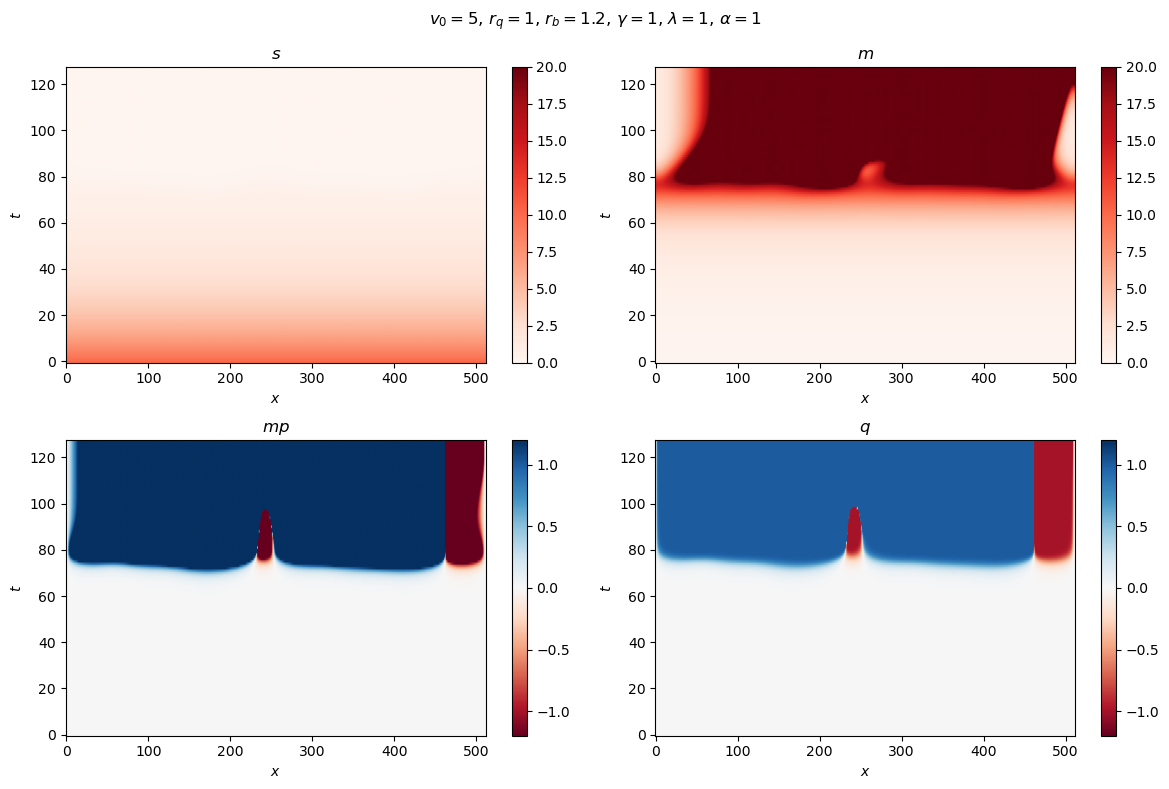

In [ ]:
s = sol.y[0:Nx]
m = sol.y[Nx:2*Nx]
p = sol.y[2*Nx:3*Nx]
q = sol.y[3*Nx:4*Nx]

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

plt.suptitle(f'$v_0 = {v0}$, $r_q = {rq}$, $r_b = {rbm}$, $\\gamma = {gamma}$, $\\lambda = {lam}$, $\\alpha = {alpha}$')

clim = (0, 20)

im1 = axs[0,0].imshow(s.T, aspect='auto', origin='lower', cmap='Reds', clim=clim)
axs[0,0].set_title(r'$s$')
axs[0,0].set_xlabel(r'$x$')
axs[0,0].set_ylabel(r'$t$')
plt.colorbar(im1, ax=axs[0,0])

im2 = axs[0,1].imshow(m.T, aspect='auto', origin='lower', cmap='Reds', clim=clim)
axs[0,1].set_title(r'$m$')
axs[0,1].set_xlabel(r'$x$')
axs[0,1].set_ylabel(r'$t$')
plt.colorbar(im2, ax=axs[0,1])

clim = (-1.2, 1.2)

im3 = axs[1,0].imshow((m * p).T, aspect='auto', origin='lower', cmap='RdBu', clim=clim)
axs[1,0].set_title(r'$mp$')
axs[1,0].set_xlabel(r'$x$')
axs[1,0].set_ylabel(r'$t$')
plt.colorbar(im3, ax=axs[1,0])

im4 = axs[1,1].imshow(q.T, aspect='auto', origin='lower', cmap='RdBu', clim=clim)
axs[1,1].set_title(r'$q$')
axs[1,1].set_xlabel(r'$x$')
axs[1,1].set_ylabel(r'$t$')
plt.colorbar(im4, ax=axs[1,1])

plt.tight_layout()

# Create v3 directory if it doesn't exist
os.makedirs('v3', exist_ok=True)

fig_name = f'phase_field_{bd}_K{Km}_v0{v0}_rq{rq}_rb_{rbm}_lam{lam}_alpha{alpha}_xt.png'
# plt.savefig(os.path.join('v3', fig_name), dpi=300)

# V4: 

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from numba import njit
import os


In [72]:
L = 50.0          # domain size
Nx = 512        # number of grid points
dx = L / Nx
x = np.linspace(0, L, Nx)

Km = 1
v0 = 10

rq = 1

lam = 1
a = -1.0
b = 1.0
c = 1
gamma = 1

alpha = 1

bd = 'gauss'
rbm = 2

if bd == 'homo':
    rb = np.ones_like(x) * rbm

elif bd == 'gauss':
    rb = rbm * np.exp(-((x - L/5)**2) / (2*(L/20)**2))


    

def laplacian(u):
    lap = np.zeros_like(u)
    lap[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    lap[0] = lap[1]       # Neumann BC
    lap[-1] = lap[-2]
    return lap

def gradient(u):
    grad = np.zeros_like(u)
    grad[1:-1] = (u[2:] - u[:-2]) / (2*dx)
    grad[0] = grad[1]
    grad[-1] = grad[-2]
    return grad


def rhs(t, Y):
    s = Y[0:Nx]
    m = Y[Nx:2*Nx]
    p = Y[2*Nx:3*Nx]
    q = Y[3*Nx:4*Nx]

    ds = (
        laplacian(s)
        + s * (1 - m - s)
        - (rq * np.abs(q) + rb * np.heaviside(250 - t, 0.5)) * s * (1 - m - s)
    )

    flux = v0 * m * p
    dm = (
        -gradient(flux)
        + laplacian(m)
        + m * (1 - m - s)
        - Km * m * s
        + (rq * np.abs(q) + rb * np.heaviside(250 - t, 0.5)) * s * (1 - m - s)
    )

    dp = -lam * (
        a * p
        + b * p**3
        - c * laplacian(p)
        + 2 * gamma * p
        - gamma * q
    )

    dq = alpha * m * p * (1 - np.abs(q))

    p[0] = 0
    p[1] = 0
    p[-1] = 0
    p[-2] = 0

    return np.concatenate([ds, dm, dp, dq])


In [73]:
s0 = np.ones_like(x) * 0.99
m0 = np.zeros_like(x)

np.random.seed(1234)

a, b = -1, 1

p0 = np.zeros_like(x) + 0.0001 * ((b - a) * np.random.random_sample(Nx) + a)
p0[0] = 0
p0[1] = 0
p0[-1] = 0
p0[-2] = 0
q0 = np.zeros_like(x)

Y0 = np.concatenate([s0, m0, p0, q0])


t_span = (0, 500)
t_eval = np.linspace(*t_span, 512)



sol = solve_ivp(
    rhs, t_span, Y0,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-6,
    atol=1e-8
)


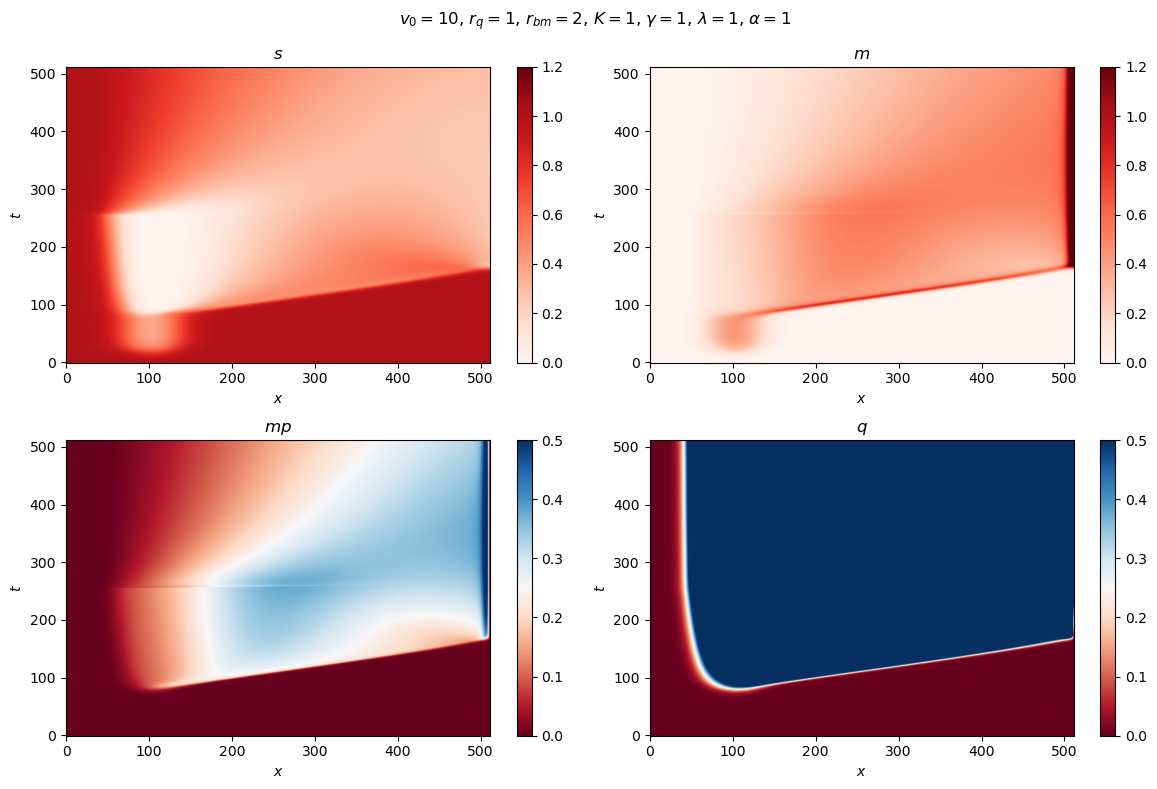

In [ ]:
s = sol.y[0:Nx]
m = sol.y[Nx:2*Nx]
p = sol.y[2*Nx:3*Nx]
q = sol.y[3*Nx:4*Nx]

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

plt.suptitle(f'$v_0 = {v0}$, $r_q = {rq}$, $r_{{bm}} = {rbm}$, $K = {Km}$, $\\gamma = {gamma}$, $\\lambda = {lam}$, $\\alpha = {alpha}$')

clim = (0, 1.2)

im1 = axs[0,0].imshow(s.T, aspect='auto', origin='lower', cmap='Reds', clim=clim)
axs[0,0].set_title(r'$s$')
axs[0,0].set_xlabel(r'$x$')
axs[0,0].set_ylabel(r'$t$')
plt.colorbar(im1, ax=axs[0,0])

im2 = axs[0,1].imshow(m.T, aspect='auto', origin='lower', cmap='Reds', clim=clim)
axs[0,1].set_title(r'$m$')
axs[0,1].set_xlabel(r'$x$')
axs[0,1].set_ylabel(r'$t$')
plt.colorbar(im2, ax=axs[0,1])

clim = (0, 0.5)

im3 = axs[1,0].imshow((m * p).T, aspect='auto', origin='lower', cmap='RdBu', clim=clim)
axs[1,0].set_title(r'$mp$')
axs[1,0].set_xlabel(r'$x$')
axs[1,0].set_ylabel(r'$t$')
plt.colorbar(im3, ax=axs[1,0])

im4 = axs[1,1].imshow(q.T, aspect='auto', origin='lower', cmap='RdBu', clim=clim)
axs[1,1].set_title(r'$q$')
axs[1,1].set_xlabel(r'$x$')
axs[1,1].set_ylabel(r'$t$')
plt.colorbar(im4, ax=axs[1,1])

plt.tight_layout()

# Create v4 directory if it doesn't exist
os.makedirs('v4', exist_ok=True)

fig_name = f'phase_field_{bd}_K{Km}_v0{v0}_rq{rq}_rb_{rbm}_lam{lam}_alpha{alpha}_xt.png'
# plt.savefig(os.path.join('v4', fig_name), dpi=300)

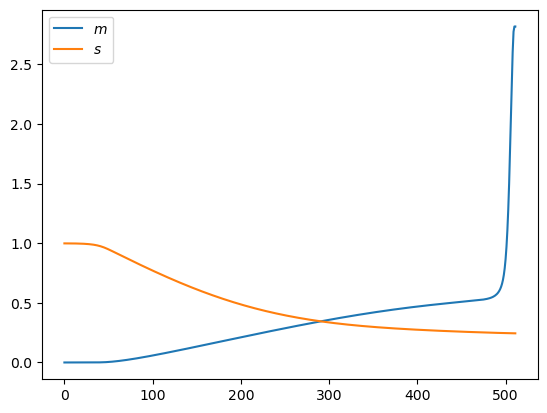

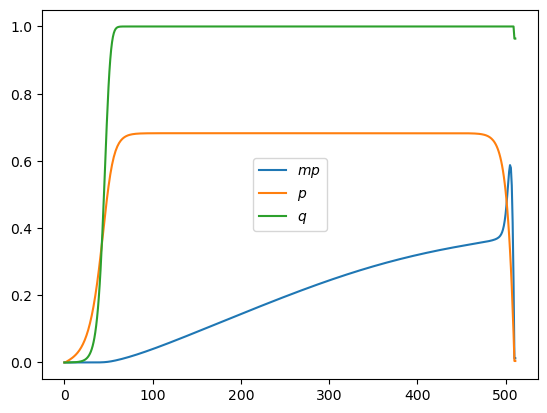

In [75]:
t = 400

plt.figure()
plt.plot(m[:, t], label=r'$m$')
plt.plot(s[:, t], label=r'$s$')

plt.legend()

plt.figure()
plt.plot(m[:, t] * p[:, t], label=r'$mp$')
plt.plot(p[:, t], label=r'$p$')
plt.plot(q[:, t], label=r'$q$')
plt.legend()

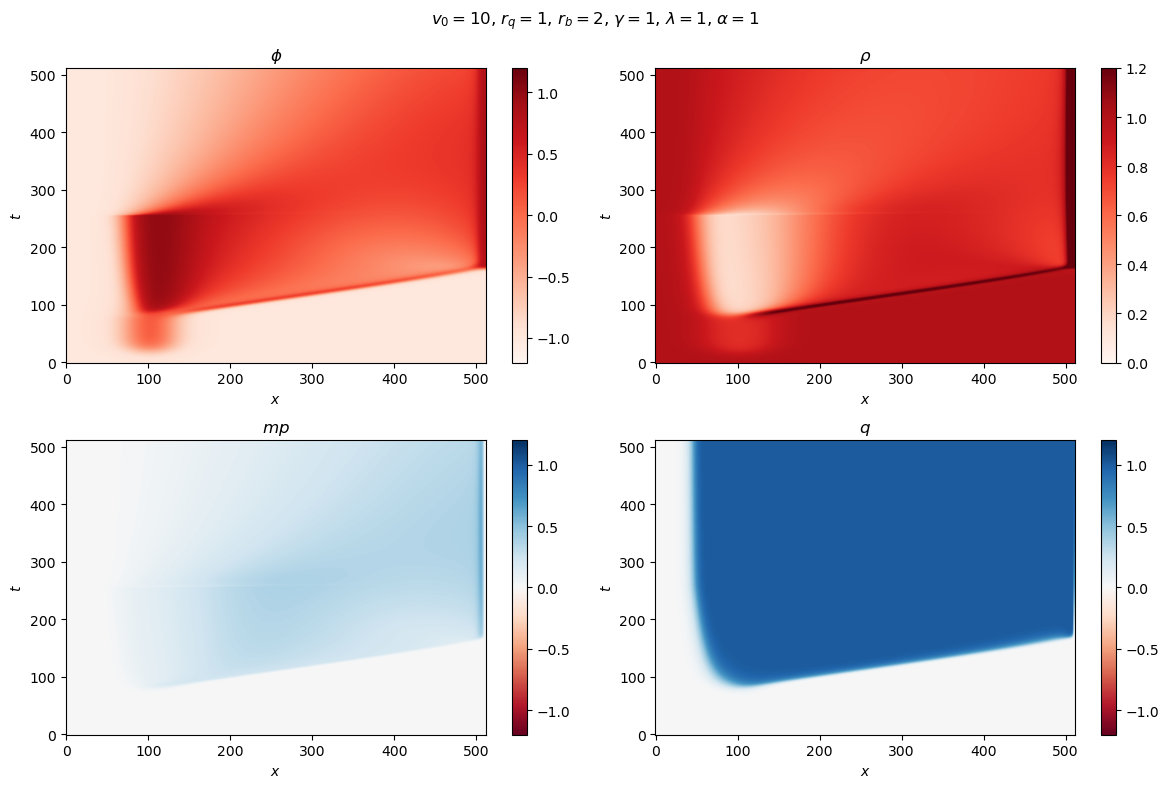

In [77]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

plt.suptitle(f'$v_0 = {v0}$, $r_q = {rq}$, $r_b = {rbm}$, $\\gamma = {gamma}$, $\\lambda = {lam}$, $\\alpha = {alpha}$')

clim = (0, 1.2)

rho = m + s
phi = (m - s) / rho

im1 = axs[0,0].imshow(phi.T, aspect='auto', origin='lower', cmap='Reds', clim=(-1.2, 1.2))
axs[0,0].set_title(r'$\phi$')
axs[0,0].set_xlabel(r'$x$')
axs[0,0].set_ylabel(r'$t$')
plt.colorbar(im1, ax=axs[0,0])

im2 = axs[0,1].imshow(rho.T, aspect='auto', origin='lower', cmap='Reds', clim=clim)
axs[0,1].set_title(r'$\rho$')
axs[0,1].set_xlabel(r'$x$')
axs[0,1].set_ylabel(r'$t$')
plt.colorbar(im2, ax=axs[0,1])

clim = (-1.2, 1.2)

im3 = axs[1,0].imshow((m * p).T, aspect='auto', origin='lower', cmap='RdBu', clim=clim)
axs[1,0].set_title(r'$mp$')
axs[1,0].set_xlabel(r'$x$')
axs[1,0].set_ylabel(r'$t$')
plt.colorbar(im3, ax=axs[1,0])

im4 = axs[1,1].imshow(q.T, aspect='auto', origin='lower', cmap='RdBu', clim=clim)
axs[1,1].set_title(r'$q$')
axs[1,1].set_xlabel(r'$x$')
axs[1,1].set_ylabel(r'$t$')
plt.colorbar(im4, ax=axs[1,1])

plt.tight_layout()

# V5: From scratch

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from numba import njit
import os


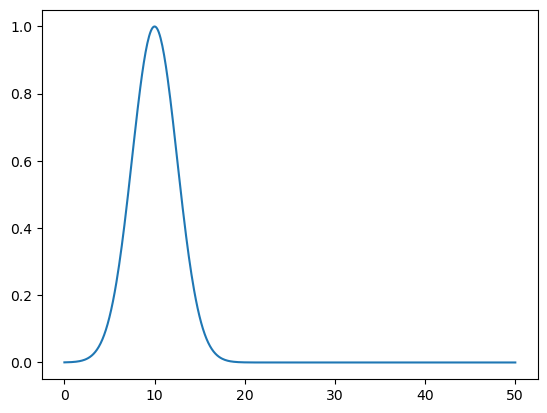

In [3]:

plt.plot(x, Nb, label='a')

In [96]:
L = 50.0          # domain size
Nx = 512        # number of grid points
dx = L / Nx
x = np.linspace(0, L, Nx)



K = 1
v0 = 10
rs = 1
rm = 1
alph = 1
rq = 0.5

lam = 1
a = -1.0
b = 1.0
c = 0.5
gamma = 1

alpha = 0.1

bd = 'homo'
Nbd = 5
rbm = 1
# width (in grid points) of each Nb=1 zone
bw = 10


if bd == 'homo':
    Nb = np.ones_like(x) * rbm

elif bd == 'pol':
    Nb = rbm * np.exp(-((x - L/5)**2) / (2*(L/20)**2))



# # Build rb and Nb arrays depending on boundary/distribution choice
# if bd == 'homo':
#     rb = np.ones_like(x) * rbm
#     Nb = np.zeros_like(x)
#     # place Nbd equidistant zones where Nb = 1, each of width `bw` grid points
#     # avoid borders by starting from bw//2 and ending at Nx - bw//2
#     marg = 20
#     centers = np.linspace(marg, Nx - 1 - marg, Nbd, dtype=int)
#     half = bw // 2
#     for c in centers:
#         i0 = max(0, c - half)
#         i1 = min(Nx, c + half)
#         Nb[i0:i1] = 1

# elif bd == 'pol':
#     rb = np.ones_like(x) * rbm
#     Nb = np.zeros_like(x)
#     # place Nbd equidistant zones where Nb = 1, each of width `bw` grid points
#     # avoid borders by starting from bw//2
#     marg = 20
#     centers = np.linspace(marg, Nx/2 - 1, Nbd, dtype=int)
#     half = bw // 2
#     for c in centers:
#         i0 = max(0, c - half)
#         i1 = min(Nx, c + half)
#         Nb[i0:i1] = 1

    

def laplacian(u):
    lap = np.zeros_like(u)
    lap[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    lap[0] = lap[1]       # Neumann BC
    lap[-1] = lap[-2]
    return lap

def gradient(u):
    grad = np.zeros_like(u)
    grad[1:-1] = (u[2:] - u[:-2]) / (2*dx)
    grad[0] = grad[1]
    grad[-1] = grad[-2]
    return grad


def rhs(t, Y):
    s = Y[0:Nx]
    m = Y[Nx:2*Nx]
    p = Y[2*Nx:3*Nx]
    q = Y[3*Nx:4*Nx]

    ds = (
        + laplacian(s)
        + s * (rs - (rbm * Nb + rq * np.abs(q)) - alph * (m + s))
    )

    flux = v0 * m * p
    dm = (
        -gradient(m) * v0 * p
        + laplacian(m)
        + m * (rm - K * s - alph * (m + s))
        + s * (rbm * Nb + rq * np.abs(q))
    )

    dp = -lam * (
        a * p
        + b * p**3
        - c * laplacian(p)
        + 2 * gamma * p
        - gamma * q
    )

    


    dq = alpha * m * p * (1 - np.abs(q))

    p[0] = 0
    p[1] = 0
    p[-1] = 0
    p[-2] = 0

    return np.concatenate([ds, dm, dp, dq])


In [97]:
s0 = np.ones_like(x) * 0.999 #- Nb
m0 = np.ones_like(x) * 0.000

# np.random.seed(1234)

a, b = -1, 1

p0 = np.zeros_like(x) + 0.00001 * ((b - a) * np.random.random_sample(Nx) + a)
p0[0] = 0
p0[1] = 0
p0[-1] = 0
p0[-2] = 0
q0 = np.zeros_like(x)

Y0 = np.concatenate([s0, m0, p0, q0])


t_span = (0, 500)
t_eval = np.linspace(*t_span, 512)



sol = solve_ivp(
    rhs, t_span, Y0,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-6,
    atol=1e-8
)


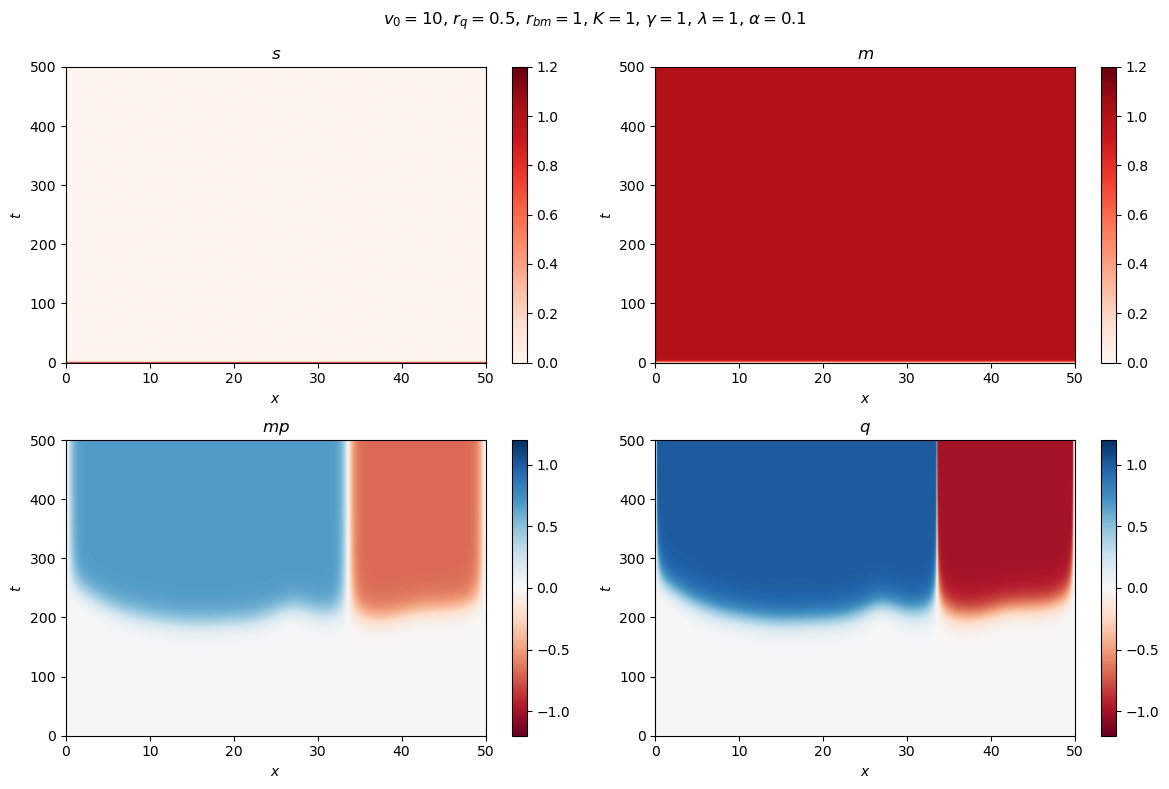

In [98]:
s = sol.y[0:Nx]
m = sol.y[Nx:2*Nx]
p = sol.y[2*Nx:3*Nx]
q = sol.y[3*Nx:4*Nx]

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

plt.suptitle(f'$v_0 = {v0}$, $r_q = {rq}$, $r_{{bm}} = {rbm}$, $K = {K}$, $\\gamma = {gamma}$, $\\lambda = {lam}$, $\\alpha = {alpha}$')

clim = (0, 1.2)

im1 = axs[0,0].imshow(s.T, aspect='auto', origin='lower', cmap='Reds', clim=clim, extent=[0, L, t_span[0], t_span[1]])
axs[0,0].set_title(r'$s$')
axs[0,0].set_xlabel(r'$x$')
axs[0,0].set_ylabel(r'$t$')
plt.colorbar(im1, ax=axs[0,0])

im2 = axs[0,1].imshow(m.T, aspect='auto', origin='lower', cmap='Reds', clim=clim, extent=[0, L, t_span[0], t_span[1]])
axs[0,1].set_title(r'$m$')
axs[0,1].set_xlabel(r'$x$')
axs[0,1].set_ylabel(r'$t$')
plt.colorbar(im2, ax=axs[0,1])

clim = (-1.2, 1.2)

im3 = axs[1,0].imshow((m * p).T, aspect='auto', origin='lower', cmap='RdBu', clim=clim, extent=[0, L, t_span[0], t_span[1]])
axs[1,0].set_title(r'$mp$')
axs[1,0].set_xlabel(r'$x$')
axs[1,0].set_ylabel(r'$t$')
plt.colorbar(im3, ax=axs[1,0])

im4 = axs[1,1].imshow(q.T, aspect='auto', origin='lower', cmap='RdBu', clim=clim, extent=[0, L, t_span[0], t_span[1]])
axs[1,1].set_title(r'$q$')
axs[1,1].set_xlabel(r'$x$')
axs[1,1].set_ylabel(r'$t$')
plt.colorbar(im4, ax=axs[1,1])

plt.tight_layout()

# Create v5 directory if it doesn't exist
# os.makedirs('v5', exist_ok=True)

# fig_name = f'phase_field_{bd}_K{K}_v0{v0}_rq{rq}_rb_{rbm}_lam{lam}_alpha{alpha}_xt.png'
# plt.savefig(os.path.join('v5', fig_name), dpi=300)

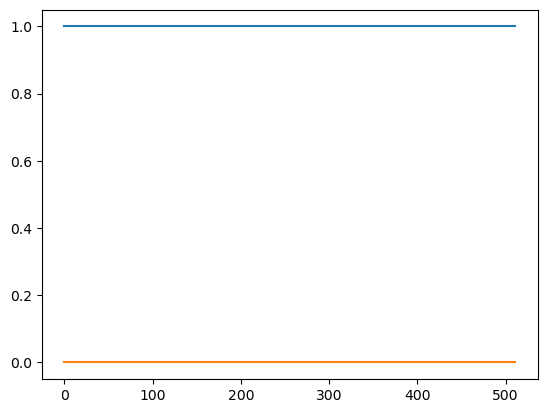

In [23]:
t = -1
plt.plot(m[:, t])
plt.plot(s[:, t])

# V6: Equation for phi

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from numba import njit
import os


In [6]:
L = 50.0          # domain size
Nx = 512        # number of grid points
dx = L / Nx
x = np.linspace(0, L, Nx)


# parameters psi
lam_psi = 1
kap_psi = 1
D_psi = 1
v0 = 15

# parameters p
lam_p = 0.5
a = -1.0
b = 1.0
D_p = 0.1
gamma = 1

#parameters q
alpha = 0.5

# parameters rb
rq = 0.1
bd = 'gauss'
rbm = 0.4

if bd == 'homo':
    rb = np.ones_like(x) * rbm

elif bd == 'gauss':
    rb = rbm * np.exp(-((x - L/5)**2) / (2*(L/25)**2))


def t_off(t):
    return 1 if t < 100 else 0
    # return 1

# functions    
def laplacian(u):
    lap = np.zeros_like(u)
    lap[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    lap[0] = lap[1]       # Neumann BC
    lap[-1] = lap[-2]
    return lap

def gradient(u):
    grad = np.zeros_like(u)
    grad[1:-1] = (u[2:] - u[:-2]) / (2*dx)
    grad[0] = grad[1]
    grad[-1] = grad[-2]
    return grad


def rhs(t, Y):
    psi = Y[0:Nx]
    p = Y[Nx:2*Nx]
    q = Y[2*Nx:3*Nx]

    dpsi = (
        -gradient((1 - psi**2) * v0 * p / 2)
        + laplacian(D_psi * psi)
        - lam_psi * (psi * (psi**2 - 1) - (rb * t_off(t) + rq * np.abs(q)) * (1 - psi))
    )

    u = v0*p*(1 - (psi + 1)/2) 
    dp = (-lam_p * (
    a * p
    + b * p**3
    - D_p * laplacian(p)
    + 2 * gamma * p
    - gamma * q
    ) - u * gradient(p)
    )


    dq = alpha * (1 + psi) / 2 * p * (1 - np.abs(q))

    p[0] = 0
    p[-1] = 0

    return np.concatenate([dpsi, dp, dq])


In [7]:
psi0 = -np.ones_like(x) * 1

# np.random.seed(1234)

a, b = -0, 1

p0 = np.zeros_like(x) + 0.0000001 * ((b - a) * np.random.random_sample(Nx) + a)
p0[0] = 0
p0[1] = 0
p0[-1] = 0
p0[-2] = 0
q0 = np.zeros_like(x)

Y0 = np.concatenate([psi0, p0, q0])


t_span = (0, 500)
t_eval = np.linspace(*t_span, 512)



sol = solve_ivp(
    rhs, t_span, Y0,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-6,
    atol=1e-8
)


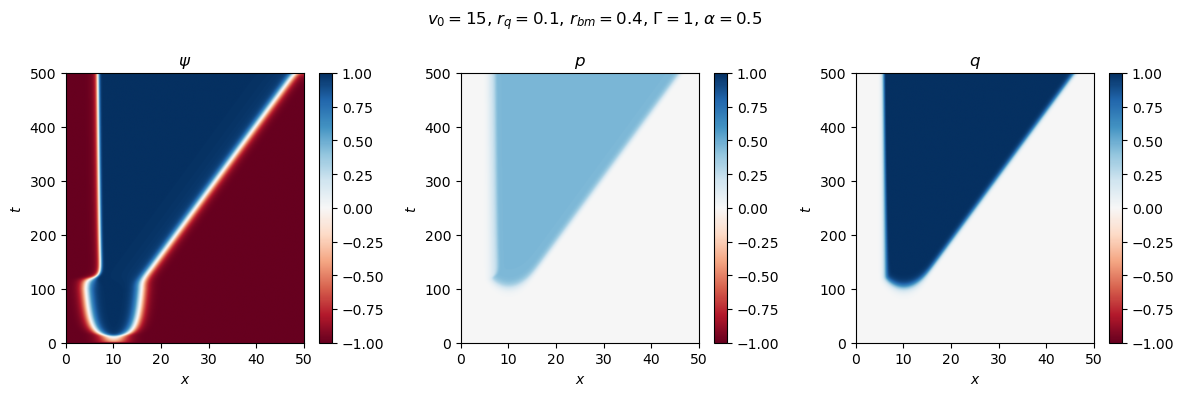

In [8]:
psi = sol.y[0:Nx]
p = sol.y[Nx:2*Nx]
q = sol.y[2*Nx:3*Nx]

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

plt.suptitle(f'$v_0 = {v0}$, $r_q = {rq}$, $r_{{bm}} = {rbm}$, $\\Gamma = {gamma}$, $\\alpha = {alpha}$')

clim = (-1, 1)

im1 = axs[0].imshow(psi.T, aspect='auto', origin='lower', cmap='RdBu', clim=clim, extent=[x[0], x[-1], t_span[0], t_span[1]])
axs[0].set_title(r'$\psi$')
axs[0].set_xlabel(r'$x$')
axs[0].set_ylabel(r'$t$')
plt.colorbar(im1, ax=axs[0])


im2 = axs[1].imshow(p.T, aspect='auto', origin='lower', cmap='RdBu', clim=clim, extent=[x[0], x[-1], t_span[0], t_span[1]])
axs[1].set_title(r'$p$')
axs[1].set_xlabel(r'$x$')
axs[1].set_ylabel(r'$t$')
plt.colorbar(im2, ax=axs[1])

im3 = axs[2].imshow(q.T, aspect='auto', origin='lower', cmap='RdBu', clim=clim, extent=[x[0], x[-1], t_span[0], t_span[1]])
axs[2].set_title(r'$q$')
axs[2].set_xlabel(r'$x$')
axs[2].set_ylabel(r'$t$')
plt.colorbar(im3, ax=axs[2])


plt.tight_layout()

# Create v5 directory if it doesn't exist
os.makedirs('psi_model', exist_ok=True)

# fig_name = f'phase_field_{bd}_v0{v0}_rq{rq}_rb_{rbm}_gam{gamma}_xt.png'
# plt.savefig(os.path.join('psi_model', fig_name), dpi=300)

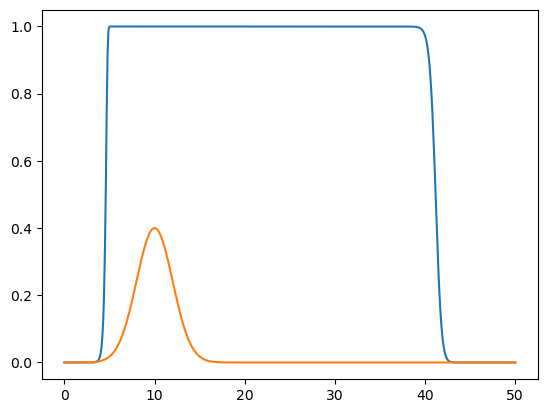

In [85]:
plt.plot(x, q[:, -1])
plt.plot(x, rb)

# psi 2D no current rho

In [ ]:
import numpy as np
from numba import njit

# -----------------------
# Helpers: index clamping for Neumann BC
# -----------------------
@njit(inline="always")
def clamp(i, lo, hi):
    if i < lo:
        return lo
    if i > hi:
        return hi
    return i

# -----------------------
# Operators (Neumann via clamped indexing)
# -----------------------
@njit(cache=True, fastmath=True)
def laplacian_neumann(u, out, dx, dy):
    ny, nx = u.shape
    idx2 = 1.0 / (dx * dx)
    idy2 = 1.0 / (dy * dy)
    for j in range(ny):
        jm = clamp(j - 1, 0, ny - 1)
        jp = clamp(j + 1, 0, ny - 1)
        for i in range(nx):
            im = clamp(i - 1, 0, nx - 1)
            ip = clamp(i + 1, 0, nx - 1)
            out[j, i] = (u[j, ip] - 2.0*u[j, i] + u[j, im]) * idx2 + (u[jp, i] - 2.0*u[j, i] + u[jm, i]) * idy2

@njit(cache=True, fastmath=True)
def gradx_neumann(u, out, dx):
    ny, nx = u.shape
    inv2dx = 1.0 / (2.0 * dx)
    for j in range(ny):
        for i in range(nx):
            im = clamp(i - 1, 0, nx - 1)
            ip = clamp(i + 1, 0, nx - 1)
            out[j, i] = (u[j, ip] - u[j, im]) * inv2dx

@njit(cache=True, fastmath=True)
def grady_neumann(u, out, dy):
    ny, nx = u.shape
    inv2dy = 1.0 / (2.0 * dy)
    for j in range(ny):
        jm = clamp(j - 1, 0, ny - 1)
        jp = clamp(j + 1, 0, ny - 1)
        for i in range(nx):
            out[j, i] = (u[jp, i] - u[jm, i]) * inv2dy

@njit(cache=True, fastmath=True)
def clamp_zero_boundary(u):
    ny, nx = u.shape
    for i in range(nx):
        u[0, i] = 0.0
        u[ny-1, i] = 0.0
    for j in range(ny):
        u[j, 0] = 0.0
        u[j, nx-1] = 0.0

# -----------------------
# RHS for (psi, px, py, qx, qy)
# -----------------------
@njit(cache=True, fastmath=True)
def rhs_vec(
    psi, px, py, qx, qy,
    dpsi, dpx, dpy, dqx, dqy,
    rb, t, dx, dy,
    lam_psi, D_psi, v0,
    lam_p, a, b, D_p, gamma,
    alpha, rq
):
    ny, nx = psi.shape

    # workspace arrays (allocated outside ideally, but OK here if called from rk4_step that preallocs)
    # -> We pass preallocated work arrays in rk4_step to avoid allocations.
    # So here we assume caller already computed needed ops.

    # We'll compute:
    # dpsi = -div(F) + D_psi*lap(psi) - lam_psi*( psi*(psi^2-1) - (rb + rq*||q||)*(1-psi) )
    # dpx, dpy component-wise GL + coupling to qx,qy
    # dq = alpha*(1+psi)/2 * p * (1-||q||)

    # Norm q
    # Flux pref = (1-psi^2)*v0/2
    # Use Neumann operators via helper ops called from rk4_step (faster, reusing work arrays).

    # This function assumes the following temporaries are stored in:
    # dqx,dqy temporarily as Fx,Fy; and dpx,dpy temporarily as lap px, lap py? -> too confusing.
    # So: do everything explicitly with local loops, and use extra work arrays passed via rk4_step.

    # (We will not call this directly; see rk4_step below.)
    pass

# -----------------------
# One RK4 step with preallocated work arrays (fast, no allocations)
# -----------------------
@njit(cache=True, fastmath=True)
def rk4_step(
    psi, px, py, qx, qy, gradxP, gradyP,
    rb, t, dt, dx, dy,
    lam_psi, D_psi, v0,
    lam_p, a, b, D_p, gamma,
    alpha, rq,
    # k arrays
    k1_psi, k1_px, k1_py, k1_qx, k1_qy,
    k2_psi, k2_px, k2_py, k2_qx, k2_qy,
    k3_psi, k3_px, k3_py, k3_qx, k3_qy,
    k4_psi, k4_px, k4_py, k4_qx, k4_qy,
    # temp state arrays
    tmp_psi, tmp_px, tmp_py, tmp_qx, tmp_qy,
    # work arrays for ops
    lap_psi, lap_px, lap_py,
    Fx, Fy, divF,
    gx, gy
):
    ny, nx = psi.shape

    def compute_rhs(psi_, px_, py_, qx_, qy_, out_psi, out_px, out_py, out_qx, out_qy, t_):
        # q norm
        for j in range(ny):
            for i in range(nx):
                # reuse gx as qnorm temporarily
                gx[j, i] = np.sqrt(qx_[j, i]*qx_[j, i] + qy_[j, i]*qy_[j, i])

        # Flux F = pref * p
        for j in range(ny):
            for i in range(nx):
                pref = (1.0 - psi_[j, i]*psi_[j, i]) * v0 * 0.5
                Fx[j, i] = pref * px_[j, i]
                Fy[j, i] = pref * py_[j, i]

        # div(F)
        gradx_neumann(Fx, divF, dx)     # divF = dFx/dx
        grady_neumann(Fy, gy, dy)       # gy = dFy/dy
        for j in range(ny):
            for i in range(nx):
                divF[j, i] = divF[j, i] + gy[j, i]

        # laplacians
        laplacian_neumann(psi_, lap_psi, dx, dy)
        laplacian_neumann(px_,  lap_px,  dx, dy)
        laplacian_neumann(py_,  lap_py,  dx, dy)

        # dpsi
        for j in range(ny):
            for i in range(nx):
                qnorm = gx[j, i]
                term_reac = psi_[j, i] * (psi_[j, i]*psi_[j, i] - 1.0) - (rb[j, i] + rq * qnorm) * (1.0 - psi_[j, i])
                out_psi[j, i] = -divF[j, i] + D_psi * lap_psi[j, i] - lam_psi * term_reac

        # dp (component-wise, coupled to q component)
        for j in range(ny):
            for i in range(nx):
                out_px[j, i] = -lam_p * (a*px_[j, i] + b*px_[j, i]**3 - D_p*lap_px[j, i] + 2.0*gamma*px_[j, i] - gamma*qx_[j, i])
                out_py[j, i] = -lam_p * (a*py_[j, i] + b*py_[j, i]**3 - D_p*lap_py[j, i] + 2.0*gamma*py_[j, i] - gamma*qy_[j, i])

        # enforce Dirichlet dp=0 at boundary (so p stays clamped to 0)
        clamp_zero_boundary(out_px)
        clamp_zero_boundary(out_py)

        # dq = alpha*(1+psi)/2 * p * (1 - ||q||)
        for j in range(ny):
            for i in range(nx):
                qnorm = gx[j, i]
                factor = alpha * (1.0 + psi_[j, i]) * 0.5 * (1.0 - qnorm)
                out_qx[j, i] = factor * px_[j, i]
                out_qy[j, i] = factor * py_[j, i]

    # k1
    compute_rhs(psi, px, py, qx, qy, k1_psi, k1_px, k1_py, k1_qx, k1_qy, t)

    # tmp = y + dt/2*k1
    for j in range(ny):
        for i in range(nx):
            tmp_psi[j, i] = psi[j, i] + 0.5*dt*k1_psi[j, i]
            tmp_px[j, i]  = px[j, i]  + 0.5*dt*k1_px[j, i]
            tmp_py[j, i]  = py[j, i]  + 0.5*dt*k1_py[j, i]
            tmp_qx[j, i]  = qx[j, i]  + 0.5*dt*k1_qx[j, i]
            tmp_qy[j, i]  = qy[j, i]  + 0.5*dt*k1_qy[j, i]
    clamp_zero_boundary(tmp_px)
    clamp_zero_boundary(tmp_py)

    # k2
    compute_rhs(tmp_psi, tmp_px, tmp_py, tmp_qx, tmp_qy, k2_psi, k2_px, k2_py, k2_qx, k2_qy, t + 0.5*dt)

    # tmp = y + dt/2*k2
    for j in range(ny):
        for i in range(nx):
            tmp_psi[j, i] = psi[j, i] + 0.5*dt*k2_psi[j, i]
            tmp_px[j, i]  = px[j, i]  + 0.5*dt*k2_px[j, i]
            tmp_py[j, i]  = py[j, i]  + 0.5*dt*k2_py[j, i]
            tmp_qx[j, i]  = qx[j, i]  + 0.5*dt*k2_qx[j, i]
            tmp_qy[j, i]  = qy[j, i]  + 0.5*dt*k2_qy[j, i]
    clamp_zero_boundary(tmp_px)
    clamp_zero_boundary(tmp_py)

    # k3
    compute_rhs(tmp_psi, tmp_px, tmp_py, tmp_qx, tmp_qy, k3_psi, k3_px, k3_py, k3_qx, k3_qy, t + 0.5*dt)

    # tmp = y + dt*k3
    for j in range(ny):
        for i in range(nx):
            tmp_psi[j, i] = psi[j, i] + dt*k3_psi[j, i]
            tmp_px[j, i]  = px[j, i]  + dt*k3_px[j, i]
            tmp_py[j, i]  = py[j, i]  + dt*k3_py[j, i]
            tmp_qx[j, i]  = qx[j, i]  + dt*k3_qx[j, i]
            tmp_qy[j, i]  = qy[j, i]  + dt*k3_qy[j, i]
    clamp_zero_boundary(tmp_px)
    clamp_zero_boundary(tmp_py)

    # k4
    compute_rhs(tmp_psi, tmp_px, tmp_py, tmp_qx, tmp_qy, k4_psi, k4_px, k4_py, k4_qx, k4_qy, t + dt)

    # y_{n+1} = y_n + dt/6*(k1 + 2k2 + 2k3 + k4)
    for j in range(ny):
        for i in range(nx):
            psi[j, i] += (dt/6.0) * (k1_psi[j, i] + 2.0*k2_psi[j, i] + 2.0*k3_psi[j, i] + k4_psi[j, i])
            px[j, i]  += (dt/6.0) * (k1_px[j, i]  + 2.0*k2_px[j, i]  + 2.0*k3_px[j, i]  + k4_px[j, i])
            py[j, i]  += (dt/6.0) * (k1_py[j, i]  + 2.0*k2_py[j, i]  + 2.0*k3_py[j, i]  + k4_py[j, i])
            qx[j, i]  += (dt/6.0) * (k1_qx[j, i]  + 2.0*k2_qx[j, i]  + 2.0*k3_qx[j, i]  + k4_qx[j, i])
            qy[j, i]  += (dt/6.0) * (k1_qy[j, i]  + 2.0*k2_qy[j, i]  + 2.0*k3_qy[j, i]  + k4_qy[j, i])

    clamp_zero_boundary(px)
    clamp_zero_boundary(py)

# -----------------------
# Simulation driver (Python-level)
# -----------------------
def simulate_rk4_numba(
    psi0, px0, py0, qx0, qy0,
    rb, Lx, Ly, T, dt, save_every,
    params
):
    lam_psi, D_psi, v0, lam_p, a, b, D_p, gamma, alpha, rq = params

    psi = psi0.copy()
    px  = px0.copy()
    py  = py0.copy()
    qx  = qx0.copy()
    qy  = qy0.copy()

    Ny, Nx = psi.shape
    dx = Lx / Nx
    dy = Ly / Ny

    nsteps = int(np.round(T / dt))
    nsaved = nsteps // save_every + 1

    # output arrays
    out_t  = np.empty(nsaved, dtype=np.float64)
    out_psi = np.empty((nsaved, Ny, Nx), dtype=np.float64)
    out_px  = np.empty((nsaved, Ny, Nx), dtype=np.float64)
    out_py  = np.empty((nsaved, Ny, Nx), dtype=np.float64)
    out_qx  = np.empty((nsaved, Ny, Nx), dtype=np.float64)
    out_qy  = np.empty((nsaved, Ny, Nx), dtype=np.float64)

    # preallocate k and temp/work arrays
    def zeros():
        return np.zeros((Ny, Nx), dtype=np.float64)

    k1_psi,k1_px,k1_py,k1_qx,k1_qy = zeros(),zeros(),zeros(),zeros(),zeros()
    k2_psi,k2_px,k2_py,k2_qx,k2_qy = zeros(),zeros(),zeros(),zeros(),zeros()
    k3_psi,k3_px,k3_py,k3_qx,k3_qy = zeros(),zeros(),zeros(),zeros(),zeros()
    k4_psi,k4_px,k4_py,k4_qx,k4_qy = zeros(),zeros(),zeros(),zeros(),zeros()

    tmp_psi,tmp_px,tmp_py,tmp_qx,tmp_qy = zeros(),zeros(),zeros(),zeros(),zeros()

    lap_psi, lap_px, lap_py = zeros(), zeros(), zeros()
    Fx, Fy, divF = zeros(), zeros(), zeros()
    gx, gy = zeros(), zeros()   # gx used as qnorm temp inside compute_rhs

    # save initial
    s = 0
    out_t[s] = 0.0
    out_psi[s] = psi
    out_px[s]  = px
    out_py[s]  = py
    out_qx[s]  = qx
    out_qy[s]  = qy

    t = 0.0
    for n in range(1, nsteps + 1):
        rk4_step(
            psi, px, py, qx, qy,
            rb, t, dt, dx, dy,
            lam_psi, D_psi, v0,
            lam_p, a, b, D_p, gamma,
            alpha, rq,
            k1_psi, k1_px, k1_py, k1_qx, k1_qy,
            k2_psi, k2_px, k2_py, k2_qx, k2_qy,
            k3_psi, k3_px, k3_py, k3_qx, k3_qy,
            k4_psi, k4_px, k4_py, k4_qx, k4_qy,
            tmp_psi, tmp_px, tmp_py, tmp_qx, tmp_qy,
            lap_psi, lap_px, lap_py,
            Fx, Fy, divF,
            gx, gy
        )
        t += dt

        if n % save_every == 0:
            s += 1
            out_t[s] = t
            out_psi[s] = psi
            out_px[s]  = px
            out_py[s]  = py
            out_qx[s]  = qx
            out_qy[s]  = qy

            print(n * 100 // nsteps, '% done')

    return out_t, out_psi, out_px, out_py, out_qx, out_qy

# -----------------------
# Choose dt (simple safe rule for diffusion)
# -----------------------
def suggest_dt(dx, dy, Dmax, safety=0.2):
    # For explicit schemes in 2D diffusion: dt <= 1/(2D(1/dx^2+1/dy^2))
    return safety / (2.0 * Dmax * (1.0/dx**2 + 1.0/dy**2))

In [101]:
# Domain
Lx = 50.0
Ly = 50.0
Nx = 256
Ny = 256
dx = Lx / Nx
dy = Ly / Ny
x = np.linspace(0, Lx, Nx, endpoint=False)
y = np.linspace(0, Ly, Ny, endpoint=False)
X, Y = np.meshgrid(x, y, indexing="xy")

# rb (gauss en x)
rbm = 0.5
rb = rbm * np.exp(-((X - Lx/10)**2 + (Y - Ly/2)**2) / (2*(Lx/5)**2))

# ICs
psi0 = -np.ones((Ny, Nx))
rng = np.random.default_rng(1234)
px0 = 1e-6 * (2*rng.random((Ny, Nx)) - 1)
py0 = 1e-6 * (2*rng.random((Ny, Nx)) - 1)
qx0 = np.zeros((Ny, Nx))
qy0 = np.zeros((Ny, Nx))

# clamp p on boundary
px0[0,:]=px0[-1,:]=0; px0[:,0]=px0[:,-1]=0
py0[0,:]=py0[-1,:]=0; py0[:,0]=py0[:,-1]=0

# Params
lam_psi = 1.0
D_psi   = 1.0
v0      = 10.0
lam_p   = 1.0
a       = -1.0
b       = 1.0
D_p     = 0.1
gamma   = 1.0
alpha   = 1.0
rq      = 0.2

params = (lam_psi, D_psi, v0, lam_p, a, b, D_p, gamma, alpha, rq)

# Time
T = 500.0
Dmax = max(D_psi, D_p)
dt = suggest_dt(dx, dy, Dmax, safety=0.2)
print("suggested dt =", dt)
save_every = 150  # guarda cada 20 pasos (ajusta a gusto)

t, psi_hist, px_hist, py_hist, qx_hist, qy_hist = simulate_rk4_numba(
    psi0, px0, py0, qx0, qy0,
    rb, Lx, Ly, T, dt, save_every,
    params
)

print("dt =", dt, "saved frames =", len(t))

suggested dt = 0.0019073486328125
0 % done
0 % done
0 % done
0 % done
0 % done
0 % done
0 % done
0 % done
0 % done
0 % done
0 % done
0 % done
0 % done
0 % done
0 % done
0 % done
0 % done
1 % done
1 % done
1 % done
1 % done
1 % done
1 % done
1 % done
1 % done
1 % done
1 % done
1 % done
1 % done
1 % done
1 % done
1 % done
1 % done
1 % done
2 % done
2 % done
2 % done
2 % done
2 % done
2 % done
2 % done
2 % done
2 % done
2 % done
2 % done
2 % done
2 % done
2 % done
2 % done
2 % done
2 % done
2 % done
3 % done
3 % done
3 % done
3 % done
3 % done
3 % done
3 % done
3 % done
3 % done
3 % done
3 % done
3 % done
3 % done
3 % done
3 % done
3 % done
3 % done
4 % done
4 % done
4 % done
4 % done
4 % done
4 % done
4 % done
4 % done
4 % done
4 % done
4 % done
4 % done
4 % done
4 % done
4 % done
4 % done
4 % done
4 % done
5 % done
5 % done
5 % done
5 % done
5 % done
5 % done
5 % done
5 % done
5 % done
5 % done
5 % done
5 % done
5 % done
5 % done
5 % done
5 % done
5 % done
6 % done
6 % done
6 % done
6 %

In [138]:
import h5py
from datetime import datetime

# Create filename with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"psi_model/psi_model_data/{timestamp}.h5"

# Save data to HDF5 file
with h5py.File(filename, 'w') as f:
    # Create groups
    solution_group = f.create_group('solution')
    params_group = f.create_group('parameters')
    grid_group = f.create_group('grid')
    
    # Save solution data
    solution_group.create_dataset('psi', data=psi_hist)
    solution_group.create_dataset('px', data=px_hist)
    solution_group.create_dataset('py', data=py_hist)
    solution_group.create_dataset('qx', data=qx_hist)
    solution_group.create_dataset('qy', data=qy_hist)
    solution_group.create_dataset('time', data=t)
    solution_group.create_dataset('rb', data=rb)
    
    # Save grid information
    grid_group.create_dataset('x', data=x)
    grid_group.create_dataset('y', data=y)
    grid_group.attrs['Lx'] = Lx
    grid_group.attrs['Ly'] = Ly
    grid_group.attrs['Nx'] = Nx
    grid_group.attrs['Ny'] = Ny
    grid_group.attrs['dx'] = dx
    grid_group.attrs['dy'] = dy
    
    # Save equation parameters
    params_group.attrs['lam_psi'] = lam_psi
    params_group.attrs['D_psi'] = D_psi
    params_group.attrs['v0'] = v0
    params_group.attrs['lam_p'] = lam_p
    params_group.attrs['a'] = a
    params_group.attrs['b'] = b
    params_group.attrs['D_p'] = D_p
    params_group.attrs['gamma'] = gamma
    params_group.attrs['alpha'] = alpha
    params_group.attrs['rq'] = rq
    
    # Save boundary conditions
    params_group.attrs['rbm'] = rbm
    params_group.attrs['bd'] = bd
    
    # Save time parameters
    params_group.attrs['T_final'] = T
    params_group.attrs['dt'] = dt
    params_group.attrs['save_every'] = save_every
    
    # Add metadata
    f.attrs['created'] = timestamp
    f.attrs['description'] = 'Phase field simulation with coupled psi, p, q fields'

print(f"Data saved to: {filename}")

Data saved to: psi_model/psi_model_data/20260225_170433.h5


In [ ]:
t = 500

filename = f"psi_model/psi_model_data/frames_{timestamp}/"
os.makedirs(filename, exist_ok=True)

for i in range(0, len(psi_hist), 10):
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    stride = 8
    Y_q, X_q = np.meshgrid(y[::stride], x[::stride], indexing='ij')

    # psi field
    im0 = axs[0].imshow(psi_hist[i], origin='lower', extent=[0, Lx, 0, Ly], cmap='RdBu', vmin=-1, vmax=1)
    axs[0].set_title(r'$\psi$')
    axs[0].set_xlabel('x')
    axs[0].set_ylabel('y')
    plt.colorbar(im0, ax=axs[0], label=r'$\psi$')

    # p field with quiver
    im1 = axs[1].imshow(np.sqrt(px_hist[i] ** 2 + py_hist[i] ** 2), origin='lower', extent=[0, Lx, 0, Ly], cmap='RdBu', vmin=0, vmax=1)
    axs[1].quiver(X_q, Y_q, px_hist[i][::stride, ::stride], py_hist[i][::stride, ::stride], alpha=0.6)
    axs[1].set_title(r'$\mathbf{p}$ field')
    axs[1].set_xlabel('x')
    axs[1].set_ylabel('y')
    plt.colorbar(im1, ax=axs[1], label=r'$|\mathbf{p}|$')

    # q field with quiver
    im2 = axs[2].imshow(np.sqrt(qx_hist[i] ** 2 + qy_hist[i] ** 2), origin='lower', extent=[0, Lx, 0, Ly], cmap='RdBu', vmin=0, vmax=1)
    axs[2].quiver(X_q, Y_q, qx_hist[i][::stride, ::stride], qy_hist[i][::stride, ::stride], alpha=0.6)
    axs[2].set_title(r'$\mathbf{q}$ field')
    axs[2].set_xlabel('x')
    axs[2].set_ylabel('y')
    plt.colorbar(im2, ax=axs[2], label=r'$|\mathbf{q}|$')

    plt.tight_layout()
    
    fig_name = f'{filename}frame_{i:04d}.png'
    plt.savefig(fig_name, dpi=300)
    plt.close(fig)


# Psi 2D pressure poission

In [ ]:
import numpy as np
from numba import njit

# -----------------------
# Helpers: index clamping for Neumann BC
# -----------------------
@njit(inline="always")
def clamp(i, lo, hi):
    if i < lo:
        return lo
    if i > hi:
        return hi
    return i

# -----------------------
# Operators (Neumann via clamped indexing)
# -----------------------
@njit(cache=True, fastmath=True)
def laplacian_neumann(u, out, dx, dy):
    ny, nx = u.shape
    idx2 = 1.0 / (dx * dx)
    idy2 = 1.0 / (dy * dy)
    for j in range(ny):
        jm = clamp(j - 1, 0, ny - 1)
        jp = clamp(j + 1, 0, ny - 1)
        for i in range(nx):
            im = clamp(i - 1, 0, nx - 1)
            ip = clamp(i + 1, 0, nx - 1)
            out[j, i] = (u[j, ip] - 2.0*u[j, i] + u[j, im]) * idx2 + (u[jp, i] - 2.0*u[j, i] + u[jm, i]) * idy2

@njit(cache=True, fastmath=True)
def gradx_neumann(u, out, dx):
    ny, nx = u.shape
    inv2dx = 1.0 / (2.0 * dx)
    for j in range(ny):
        for i in range(nx):
            im = clamp(i - 1, 0, nx - 1)
            ip = clamp(i + 1, 0, nx - 1)
            out[j, i] = (u[j, ip] - u[j, im]) * inv2dx

@njit(cache=True, fastmath=True)
def grady_neumann(u, out, dy):
    ny, nx = u.shape
    inv2dy = 1.0 / (2.0 * dy)
    for j in range(ny):
        jm = clamp(j - 1, 0, ny - 1)
        jp = clamp(j + 1, 0, ny - 1)
        for i in range(nx):
            out[j, i] = (u[jp, i] - u[jm, i]) * inv2dy

@njit(cache=True, fastmath=True)
def clamp_zero_boundary(u):
    ny, nx = u.shape
    for i in range(nx):
        u[0, i] = 0.0
        u[ny-1, i] = 0.0
    for j in range(ny):
        u[j, 0] = 0.0
        u[j, nx-1] = 0.0

from numba import njit
import numpy as np

@njit(cache=True, fastmath=True)
def subtract_mean(u):
    ny, nx = u.shape
    s = 0.0
    for j in range(ny):
        for i in range(nx):
            s += u[j, i]
    mean = s / (ny * nx)
    for j in range(ny):
        for i in range(nx):
            u[j, i] -= mean

@njit(cache=True, fastmath=True)
def poisson_neumann_jacobi(P, rhs, Ptmp, dx, dy, niter):
    """
    Solve Lap(P) = rhs with Neumann BC via clamped indexing.
    Gauge: enforce mean(P)=0 each iteration.
    """
    ny, nx = P.shape
    idx2 = 1.0 / (dx * dx)
    idy2 = 1.0 / (dy * dy)
    denom = 2.0 * (idx2 + idy2)

    for _ in range(niter):
        for j in range(ny):
            jm = clamp(j - 1, 0, ny - 1)
            jp = clamp(j + 1, 0, ny - 1)
            for i in range(nx):
                im = clamp(i - 1, 0, nx - 1)
                ip = clamp(i + 1, 0, nx - 1)
                nb = (P[j, ip] + P[j, im]) * idx2 + (P[jp, i] + P[jm, i]) * idy2
                Ptmp[j, i] = (nb - rhs[j, i]) / denom

        for j in range(ny):
            for i in range(nx):
                P[j, i] = Ptmp[j, i]

        subtract_mean(P)

@njit(cache=True, fastmath=True)
def solve_gradP_from_incompressibility(
    psi, px, py,
    gradPx, gradPy,   # outputs
    # work arrays (preallocated)
    Ax, Ay, divA, rhsP, P, Ptmp, tmp,
    dx, dy, v0, mu, poisson_iters
):
    ny, nx = psi.shape

    # A = v0 * m * p, with m = rho0*(1+psi)/2
    for j in range(ny):
        for i in range(nx):
            m = 0.5 * (1.0 + psi[j, i])
            Ax[j, i] = v0 * m * px[j, i]
            Ay[j, i] = v0 * m * py[j, i]

    # divA
    gradx_neumann(Ax, divA, dx)    # divA = dAx/dx
    grady_neumann(Ay, tmp, dy)     # tmp  = dAy/dy
    for j in range(ny): # sum both components
        for i in range(nx):
            divA[j, i] += tmp[j, i]

    # rhsP = -(1/mu) divA
    inv = -1.0 / (mu)
    for j in range(ny):
        for i in range(nx):
            rhsP[j, i] = inv * divA[j, i]

    # Neumann solvability
    subtract_mean(rhsP)

    # Solve Poisson
    poisson_neumann_jacobi(P, rhsP, Ptmp, dx, dy, poisson_iters)

    # gradP
    gradx_neumann(P, gradPx, dx)
    grady_neumann(P, gradPy, dy)




# -----------------------
# One RK4 step with preallocated work arrays (fast, no allocations)
# -----------------------
@njit(cache=True, fastmath=True)
def rk4_step(
    psi, px, py, qx, qy,
    divp,
    gradPx, gradPy, Ax, Ay, divA, rhsP, P, Ptmp, tmp, poisson_iters,
    rb, t, dt, dx, dy,
    lam_psi, D_psi, v0,
    lam_p, a, b, D_p, gamma,
    alpha, rq, mu,
    # k arrays
    k1_psi, k1_px, k1_py, k1_qx, k1_qy,
    k2_psi, k2_px, k2_py, k2_qx, k2_qy,
    k3_psi, k3_px, k3_py, k3_qx, k3_qy,
    k4_psi, k4_px, k4_py, k4_qx, k4_qy,
    # temp state arrays
    tmp_psi, tmp_px, tmp_py, tmp_qx, tmp_qy,
    # work arrays for ops
    lap_psi, lap_px, lap_py,
    Fx, Fy, divF,
    gx, gy
):
    ny, nx = psi.shape

    def compute_rhs(psi_, px_, py_, qx_, qy_, out_psi, out_px, out_py, out_qx, out_qy, t_):
        # q norm
        for j in range(ny):
            for i in range(nx):
                # reuse gx as qnorm temporarily
                gx[j, i] = np.sqrt(qx_[j, i]*qx_[j, i] + qy_[j, i]*qy_[j, i])

        # Flux F = pref * p
        for j in range(ny):
            for i in range(nx):
                pref = (1.0 + psi_[j, i]) * v0 * 0.5
                Fx[j, i] = pref * px_[j, i]
                Fy[j, i] = pref * py_[j, i]


        solve_gradP_from_incompressibility(
            psi_, px_, py_,
            gradPx, gradPy,
            Ax, Ay, divA, rhsP, P, Ptmp, tmp,
            dx, dy, v0, mu, poisson_iters
        )

        # ψ-flux: Jψ = (v0/2)(1+ψ)p + μ ψ ∇P   (and diffusion handled separately via laplacian term)
        for j in range(ny):
            for i in range(nx):
                adv_pref = 0.5 * v0 * (1.0 + psi_[j, i])
                Fx[j, i] = adv_pref * px_[j, i] + mu * psi_[j, i] * gradPx[j, i]
                Fy[j, i] = adv_pref * py_[j, i] + mu * psi_[j, i] * gradPy[j, i]

        # div(F)
        gradx_neumann(Fx, divF, dx)     # divF = dFx/dx
        grady_neumann(Fy, gy, dy)       # gy = dFy/dy
        for j in range(ny):
            for i in range(nx):
                divF[j, i] = divF[j, i] + gy[j, i]

        # laplacians
        laplacian_neumann(psi_, lap_psi, dx, dy)
        laplacian_neumann(px_,  lap_px,  dx, dy)
        laplacian_neumann(py_,  lap_py,  dx, dy)

        # dpsi
        for j in range(ny):
            for i in range(nx):
                qnorm = gx[j, i]
                term_reac = psi_[j, i] * (psi_[j, i]*psi_[j, i] - 1.0) - (rb[j, i] + rq * qnorm) * (1.0 - psi_[j, i])
                out_psi[j, i] = -divF[j, i] + D_psi * lap_psi[j, i] - lam_psi * term_reac

        # divergence of p
        gradx_neumann(px_, divp, dx)
        grady_neumann(py_, gy, dy)
        for j in range(ny):
            for i in range(nx):
                divp[j, i] = divp[j, i] + gy[j, i]

        # dp (component-wise, coupled to q component)
   
        for j in range(ny):
            for i in range(nx):
                Jmx = v0 * px_[j, i] + mu * gradPx[j, i] # advection terms for p, ignoring diffuison
                Jmy = v0 * py_[j, i] + mu * gradPy[j, i]
                out_px[j, i] = -lam_p * (a*px_[j, i] + b*px_[j, i]**3 - D_p*lap_px[j, i] + 2.0*gamma*px_[j, i] - gamma*qx_[j, i]) - Jmx * divp[j, i]
                out_py[j, i] = -lam_p * (a*py_[j, i] + b*py_[j, i]**3 - D_p*lap_py[j, i] + 2.0*gamma*py_[j, i] - gamma*qy_[j, i]) - Jmy * divp[j, i]

        # enforce Dirichlet dp=0 at boundary (so p stays clamped to 0)
        clamp_zero_boundary(out_px)
        clamp_zero_boundary(out_py)

        # dq = alpha*(1+psi)/2 * p * (1 - ||q||)
        for j in range(ny):
            for i in range(nx):
                qnorm = gx[j, i]
                factor = alpha * (1.0 + psi_[j, i]) * 0.5 * (1.0 - qnorm)
                out_qx[j, i] = factor * px_[j, i]
                out_qy[j, i] = factor * py_[j, i]

    # k1
    compute_rhs(psi, px, py, qx, qy, k1_psi, k1_px, k1_py, k1_qx, k1_qy, t)

    # tmp = y + dt/2*k1
    for j in range(ny):
        for i in range(nx):
            tmp_psi[j, i] = psi[j, i] + 0.5*dt*k1_psi[j, i]
            tmp_px[j, i]  = px[j, i]  + 0.5*dt*k1_px[j, i]
            tmp_py[j, i]  = py[j, i]  + 0.5*dt*k1_py[j, i]
            tmp_qx[j, i]  = qx[j, i]  + 0.5*dt*k1_qx[j, i]
            tmp_qy[j, i]  = qy[j, i]  + 0.5*dt*k1_qy[j, i]
    clamp_zero_boundary(tmp_px)
    clamp_zero_boundary(tmp_py)

    # k2
    compute_rhs(tmp_psi, tmp_px, tmp_py, tmp_qx, tmp_qy, k2_psi, k2_px, k2_py, k2_qx, k2_qy, t + 0.5*dt)

    # tmp = y + dt/2*k2
    for j in range(ny):
        for i in range(nx):
            tmp_psi[j, i] = psi[j, i] + 0.5*dt*k2_psi[j, i]
            tmp_px[j, i]  = px[j, i]  + 0.5*dt*k2_px[j, i]
            tmp_py[j, i]  = py[j, i]  + 0.5*dt*k2_py[j, i]
            tmp_qx[j, i]  = qx[j, i]  + 0.5*dt*k2_qx[j, i]
            tmp_qy[j, i]  = qy[j, i]  + 0.5*dt*k2_qy[j, i]
    clamp_zero_boundary(tmp_px)
    clamp_zero_boundary(tmp_py)

    # k3
    compute_rhs(tmp_psi, tmp_px, tmp_py, tmp_qx, tmp_qy, k3_psi, k3_px, k3_py, k3_qx, k3_qy, t + 0.5*dt)

    # tmp = y + dt*k3
    for j in range(ny):
        for i in range(nx):
            tmp_psi[j, i] = psi[j, i] + dt*k3_psi[j, i]
            tmp_px[j, i]  = px[j, i]  + dt*k3_px[j, i]
            tmp_py[j, i]  = py[j, i]  + dt*k3_py[j, i]
            tmp_qx[j, i]  = qx[j, i]  + dt*k3_qx[j, i]
            tmp_qy[j, i]  = qy[j, i]  + dt*k3_qy[j, i]
    clamp_zero_boundary(tmp_px)
    clamp_zero_boundary(tmp_py)

    # k4
    compute_rhs(tmp_psi, tmp_px, tmp_py, tmp_qx, tmp_qy, k4_psi, k4_px, k4_py, k4_qx, k4_qy, t + dt)

    # y_{n+1} = y_n + dt/6*(k1 + 2k2 + 2k3 + k4)
    for j in range(ny):
        for i in range(nx):
            psi[j, i] += (dt/6.0) * (k1_psi[j, i] + 2.0*k2_psi[j, i] + 2.0*k3_psi[j, i] + k4_psi[j, i])
            px[j, i]  += (dt/6.0) * (k1_px[j, i]  + 2.0*k2_px[j, i]  + 2.0*k3_px[j, i]  + k4_px[j, i])
            py[j, i]  += (dt/6.0) * (k1_py[j, i]  + 2.0*k2_py[j, i]  + 2.0*k3_py[j, i]  + k4_py[j, i])
            qx[j, i]  += (dt/6.0) * (k1_qx[j, i]  + 2.0*k2_qx[j, i]  + 2.0*k3_qx[j, i]  + k4_qx[j, i])
            qy[j, i]  += (dt/6.0) * (k1_qy[j, i]  + 2.0*k2_qy[j, i]  + 2.0*k3_qy[j, i]  + k4_qy[j, i])

    clamp_zero_boundary(px)
    clamp_zero_boundary(py)

# -----------------------
# Simulation driver (Python-level)
# -----------------------
def simulate_rk4_numba(
    psi0, px0, py0, qx0, qy0,
    rb, Lx, Ly, T, dt, save_every,
    params, poisson_iters=5
):
    lam_psi, D_psi, v0, lam_p, a, b, D_p, gamma, alpha, rq, mu = params

    psi = psi0.copy()
    px  = px0.copy()
    py  = py0.copy()
    qx  = qx0.copy()
    qy  = qy0.copy()

    Ny, Nx = psi.shape
    dx = Lx / Nx
    dy = Ly / Ny

    nsteps = int(np.round(T / dt))
    nsaved = nsteps // save_every + 1

    # output arrays
    out_t  = np.empty(nsaved, dtype=np.float64)
    out_psi = np.empty((nsaved, Ny, Nx), dtype=np.float64)
    out_px  = np.empty((nsaved, Ny, Nx), dtype=np.float64)
    out_py  = np.empty((nsaved, Ny, Nx), dtype=np.float64)
    out_qx  = np.empty((nsaved, Ny, Nx), dtype=np.float64)
    out_qy  = np.empty((nsaved, Ny, Nx), dtype=np.float64)

    # preallocate k and temp/work arrays
    def zeros():
        return np.zeros((Ny, Nx), dtype=np.float64)

    k1_psi,k1_px,k1_py,k1_qx,k1_qy = zeros(),zeros(),zeros(),zeros(),zeros()
    k2_psi,k2_px,k2_py,k2_qx,k2_qy = zeros(),zeros(),zeros(),zeros(),zeros()
    k3_psi,k3_px,k3_py,k3_qx,k3_qy = zeros(),zeros(),zeros(),zeros(),zeros()
    k4_psi,k4_px,k4_py,k4_qx,k4_qy = zeros(),zeros(),zeros(),zeros(),zeros()

    tmp_psi,tmp_px,tmp_py,tmp_qx,tmp_qy = zeros(),zeros(),zeros(),zeros(),zeros()

    lap_psi, lap_px, lap_py = zeros(), zeros(), zeros()
    Fx, Fy, divF = zeros(), zeros(), zeros()
    gx, gy = zeros(), zeros()   # gx used as qnorm temp inside compute_rhs

    P    = zeros()
    Ptmp = zeros()
    rhsP = zeros()
    Ax   = zeros()
    Ay   = zeros()
    divA = zeros()
    divp = zeros()
    tmp  = zeros()
    gradPx = zeros()
    gradPy = zeros()

    # save initial
    s = 0
    out_t[s] = 0.0
    out_psi[s] = psi
    out_px[s]  = px
    out_py[s]  = py
    out_qx[s]  = qx
    out_qy[s]  = qy

    t = 0.0
    for n in range(1, nsteps + 1):
        rk4_step(
            psi, px, py, qx, qy,
            divp, 
            gradPx, gradPy, Ax, Ay, divA, rhsP, P, Ptmp, tmp, poisson_iters,
            rb, t, dt, dx, dy,
            lam_psi, D_psi, v0,
            lam_p, a, b, D_p, gamma,
            alpha, rq, mu,
            # k arrays
            k1_psi, k1_px, k1_py, k1_qx, k1_qy,
            k2_psi, k2_px, k2_py, k2_qx, k2_qy,
            k3_psi, k3_px, k3_py, k3_qx, k3_qy,
            k4_psi, k4_px, k4_py, k4_qx, k4_qy,
            # temp state arrays
            tmp_psi, tmp_px, tmp_py, tmp_qx, tmp_qy,
            # work arrays for ops
            lap_psi, lap_px, lap_py,
            Fx, Fy, divF,
            gx, gy
        )
        t += dt

        if n % save_every == 0:
            s += 1
            out_t[s] = t
            out_psi[s] = psi
            out_px[s]  = px
            out_py[s]  = py
            out_qx[s]  = qx
            out_qy[s]  = qy

            print(n * 100 // nsteps, '% done')

    return out_t, out_psi, out_px, out_py, out_qx, out_qy

# -----------------------
# Choose dt (simple safe rule for diffusion)
# -----------------------
def suggest_dt(dx, dy, Dmax, safety=0.2):
    # For explicit schemes in 2D diffusion: dt <= 1/(2D(1/dx^2+1/dy^2))
    return safety / (2.0 * Dmax * (1.0/dx**2 + 1.0/dy**2))

In [24]:
# Domain
Lx = 50.0
Ly = 50.0
Nx = 256
Ny = 256
dx = Lx / Nx
dy = Ly / Ny
x = np.linspace(0, Lx, Nx, endpoint=False)
y = np.linspace(0, Ly, Ny, endpoint=False)
X, Y = np.meshgrid(x, y, indexing="xy")

# rb (gauss en x)
rbm = 0.5
rb = rbm * np.exp(-((X - Lx/10)**2 + (Y - Ly/2)**2) / (2*(Lx/10)**2))

# ICs
psi0 = -np.ones((Ny, Nx))
rng = np.random.default_rng(1234)
px0 = 1e-6 * (2*rng.random((Ny, Nx)) - 1)
py0 = 1e-6 * (2*rng.random((Ny, Nx)) - 1)
qx0 = np.zeros((Ny, Nx))
qy0 = np.zeros((Ny, Nx))

# clamp p on boundary
px0[0,:]=px0[-1,:]=0; px0[:,0]=px0[:,-1]=0
py0[0,:]=py0[-1,:]=0; py0[:,0]=py0[:,-1]=0

# Params
lam_psi = 1.0
D_psi   = 0.1
v0      = 0.0
lam_p   = 0.0
a       = -1.0
b       = 1.0
D_p     = 0.1
gamma   = 1.0
alpha   = 0.0
rq      = 0.0
mu      = 1.0

params = (lam_psi, D_psi, v0, lam_p, a, b, D_p, gamma, alpha, rq, mu)

# Time
T = 1000.0
Dmax = max(D_psi, D_p)
dt = suggest_dt(dx, dy, Dmax, safety=0.2)
print("suggested dt =", dt)
save_every = 100  # guarda cada 20 pasos (ajusta a gusto)

t, psi_hist, px_hist, py_hist, qx_hist, qy_hist = simulate_rk4_numba(
    psi0, px0, py0, qx0, qy0,
    rb, Lx, Ly, T, dt, save_every,
    params
)

print("dt =", dt, "saved frames =", len(t))

suggested dt = 0.019073486328125
0 % done
0 % done
0 % done
0 % done
0 % done
1 % done
1 % done
1 % done
1 % done
1 % done
2 % done
2 % done
2 % done
2 % done
2 % done
3 % done
3 % done
3 % done
3 % done
3 % done
4 % done
4 % done
4 % done
4 % done
4 % done
4 % done
5 % done
5 % done
5 % done
5 % done
5 % done
6 % done
6 % done
6 % done
6 % done
6 % done
7 % done
7 % done
7 % done
7 % done
7 % done
8 % done
8 % done
8 % done
8 % done
8 % done
8 % done
9 % done
9 % done
9 % done
9 % done
9 % done
10 % done
10 % done
10 % done
10 % done
10 % done
11 % done
11 % done
11 % done
11 % done
11 % done
12 % done
12 % done
12 % done
12 % done
12 % done
12 % done
13 % done
13 % done
13 % done
13 % done
13 % done
14 % done
14 % done
14 % done
14 % done
14 % done
15 % done
15 % done
15 % done
15 % done
15 % done
16 % done
16 % done
16 % done
16 % done
16 % done
16 % done
17 % done
17 % done
17 % done
17 % done
17 % done
18 % done
18 % done
18 % done
18 % done
18 % done
19 % done
19 % done
19 % done

In [25]:
import h5py
from datetime import datetime

# Create filename with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"psi_model/psi_model_data/{timestamp}.h5"

# Save data to HDF5 file
with h5py.File(filename, 'w') as f:
    # Create groups
    solution_group = f.create_group('solution')
    params_group = f.create_group('parameters')
    grid_group = f.create_group('grid')
    
    # Save solution data
    solution_group.create_dataset('psi', data=psi_hist)
    solution_group.create_dataset('px', data=px_hist)
    solution_group.create_dataset('py', data=py_hist)
    solution_group.create_dataset('qx', data=qx_hist)
    solution_group.create_dataset('qy', data=qy_hist)
    solution_group.create_dataset('time', data=t)
    solution_group.create_dataset('rb', data=rb)
    
    # Save grid information
    grid_group.create_dataset('x', data=x)
    grid_group.create_dataset('y', data=y)
    grid_group.attrs['Lx'] = Lx
    grid_group.attrs['Ly'] = Ly
    grid_group.attrs['Nx'] = Nx
    grid_group.attrs['Ny'] = Ny
    grid_group.attrs['dx'] = dx
    grid_group.attrs['dy'] = dy
    
    # Save equation parameters
    params_group.attrs['lam_psi'] = lam_psi
    params_group.attrs['D_psi'] = D_psi
    params_group.attrs['v0'] = v0
    params_group.attrs['lam_p'] = lam_p
    params_group.attrs['a'] = a
    params_group.attrs['b'] = b
    params_group.attrs['D_p'] = D_p
    params_group.attrs['gamma'] = gamma
    params_group.attrs['alpha'] = alpha
    params_group.attrs['rq'] = rq
    
    # Save boundary conditions
    params_group.attrs['rbm'] = rbm
    
    # Save time parameters
    params_group.attrs['T_final'] = T
    params_group.attrs['dt'] = dt
    params_group.attrs['save_every'] = save_every
    
    # Add metadata
    f.attrs['created'] = timestamp
    f.attrs['description'] = 'Phase field simulation with coupled psi, p, q fields'

print(f"Data saved to: {filename}")

Data saved to: psi_model/psi_model_data/20260227_164808.h5


In [26]:
import os
import matplotlib.pyplot as plt

filename = f"psi_model/psi_model_data/frames_{timestamp}/"
os.makedirs(filename, exist_ok=True)

for i in range(0, len(psi_hist), 10):
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    stride = 8
    Y_q, X_q = np.meshgrid(y[::stride], x[::stride], indexing='ij')

    # psi field
    im0 = axs[0].imshow(psi_hist[i], origin='lower', extent=[0, Lx, 0, Ly], cmap='RdBu', vmin=-1, vmax=1)
    axs[0].set_title(r'$\psi$')
    axs[0].set_xlabel('x')
    axs[0].set_ylabel('y')
    plt.colorbar(im0, ax=axs[0], label=r'$\psi$')

    # p field with quiver
    im1 = axs[1].imshow(np.sqrt(px_hist[i] ** 2 + py_hist[i] ** 2), origin='lower', extent=[0, Lx, 0, Ly], cmap='RdBu', vmin=0, vmax=1)
    axs[1].quiver(X_q, Y_q, px_hist[i][::stride, ::stride], py_hist[i][::stride, ::stride], alpha=0.6)
    axs[1].set_title(r'$\mathbf{p}$ field')
    axs[1].set_xlabel('x')
    axs[1].set_ylabel('y')
    plt.colorbar(im1, ax=axs[1], label=r'$|\mathbf{p}|$')

    # q field with quiver
    im2 = axs[2].imshow(np.sqrt(qx_hist[i] ** 2 + qy_hist[i] ** 2), origin='lower', extent=[0, Lx, 0, Ly], cmap='RdBu', vmin=0, vmax=1)
    axs[2].quiver(X_q, Y_q, qx_hist[i][::stride, ::stride], qy_hist[i][::stride, ::stride], alpha=0.6)
    axs[2].set_title(r'$\mathbf{q}$ field')
    axs[2].set_xlabel('x')
    axs[2].set_ylabel('y')
    plt.colorbar(im2, ax=axs[2], label=r'$|\mathbf{q}|$')

    plt.tight_layout()
    
    fig_name = f'{filename}frame_{i:04d}.png'
    plt.savefig(fig_name, dpi=300)
    plt.close(fig)
